# The effect of degree of semantic violation on N400 and P600 effects (analysis)

# Preprocessing

In [1]:
import mne
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# reading the file & loading in the data
data_folder = Path("/work/EEG_lab/own_experiments_data")

data_raw_file_other = data_folder / 'group5_other.vhdr'

data_raw_file_own = data_folder / 'group5_own.vhdr'

raw_1 = mne.io.read_raw_brainvision(data_raw_file_other, eog=('HEOG', 'VEOG'), misc=['41'])
raw_2 = mne.io.read_raw_brainvision(data_raw_file_own, eog=('HEOG', 'VEOG'), misc=['41'])
raw_1.info['bads'] = []
raw_2.info['bads'] = []

raw_1.load_data()
raw_2.load_data()

Extracting parameters from /work/EEG_lab/own_experiments_data/group5_other.vhdr...
Setting channel info structure...
Extracting parameters from /work/EEG_lab/own_experiments_data/group5_own.vhdr...
Setting channel info structure...
Reading 0 ... 611039  =      0.000 ...   611.039 secs...


/tmp/ipykernel_906/237213871.py:8: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw_1 = mne.io.read_raw_brainvision(data_raw_file_other, eog=('HEOG', 'VEOG'), misc=['41'])
/tmp/ipykernel_906/237213871.py:9: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw_2 = mne.io.read_raw_brainvision(data_raw_file_own, eog=('HEOG', 'VEOG'), misc=['41'])


Reading 0 ... 845799  =      0.000 ...   845.799 secs...


<RawBrainVision | group5_own.eeg, 33 x 845800 (845.8 s), ~213.0 MiB, data loaded>

specifying channel locations

In [3]:
montage = mne.channels.make_standard_montage('standard_1020')
raw_1.set_montage(montage, verbose=False)
raw_2.set_montage(montage, verbose=False)

<RawBrainVision | group5_own.eeg, 33 x 845800 (845.8 s), ~213.0 MiB, data loaded>

Plotting raw data

Using matplotlib as 2D backend.


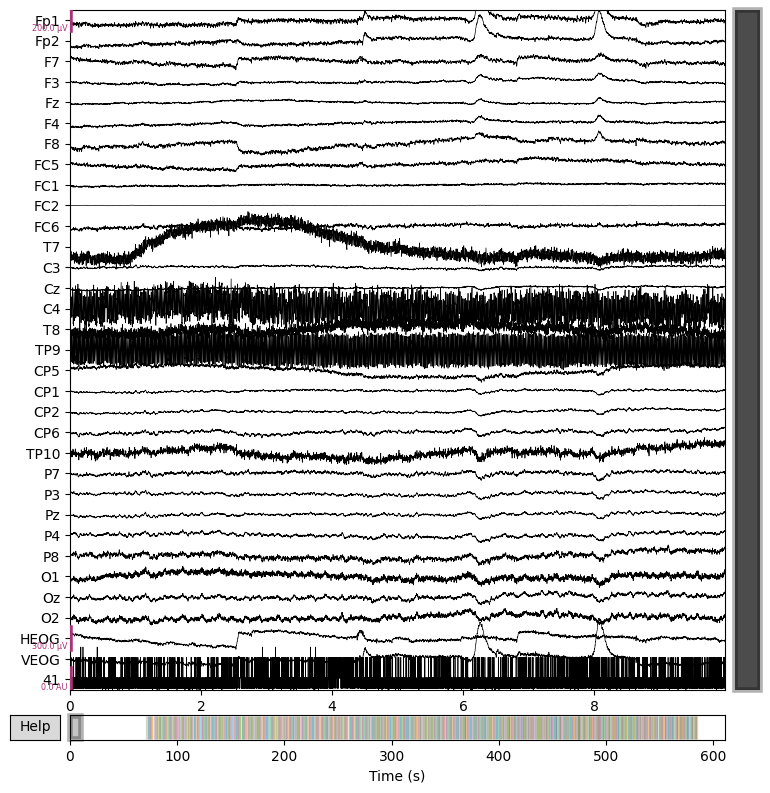

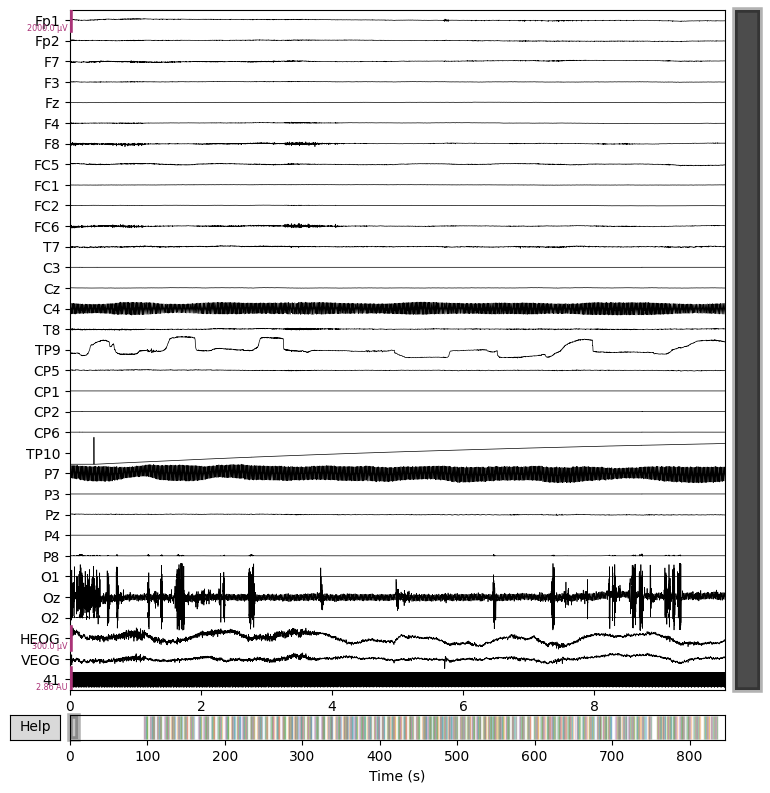

In [4]:
raw_1.plot(scalings=dict(eeg=100e-6), n_channels=33, title="Raw 1");
raw_2.plot(scalings=dict(eeg=100e-5), n_channels=33, title="Raw 2");

In [5]:
# Excluding bad channels

raw_1.info["bads"] = ['TP9', 'T7', 'C4']
raw_1.pick(exclude='bads', picks = ['eeg'])

raw_2.info["bads"] = ['TP9', 'Oz', 'P7', 'C4']
raw_2.pick(exclude='bads', picks = ['eeg'])

<RawBrainVision | group5_own.eeg, 26 x 845800 (845.8 s), ~167.8 MiB, data loaded>

Redefining the reference to a common average

In [6]:
raw_1.set_eeg_reference('average', projection=False, verbose=False)
raw_2.set_eeg_reference('average', projection=False, verbose=False)

<RawBrainVision | group5_own.eeg, 26 x 845800 (845.8 s), ~167.8 MiB, data loaded>

Filtering data

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



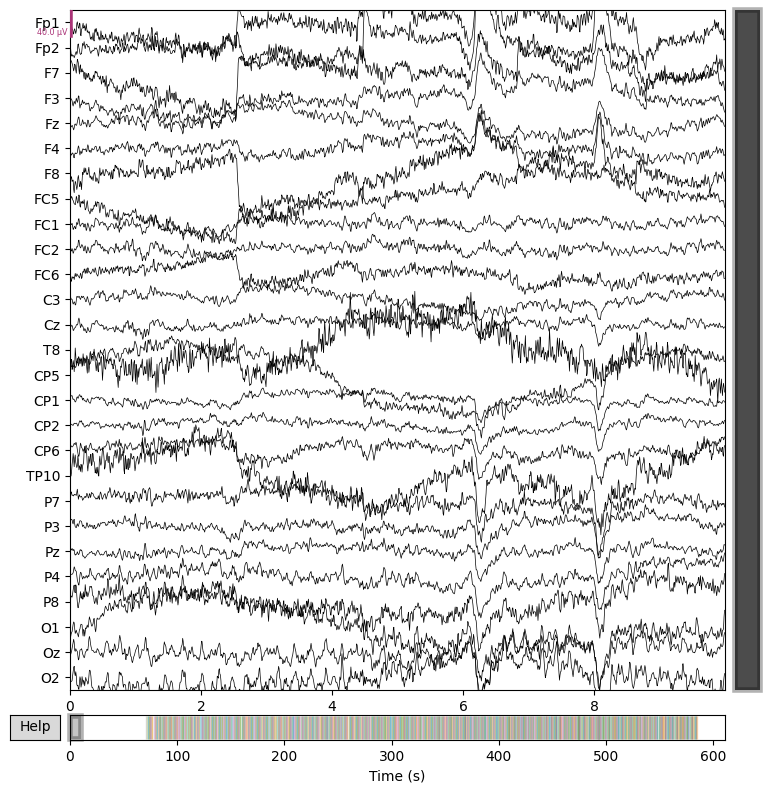

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



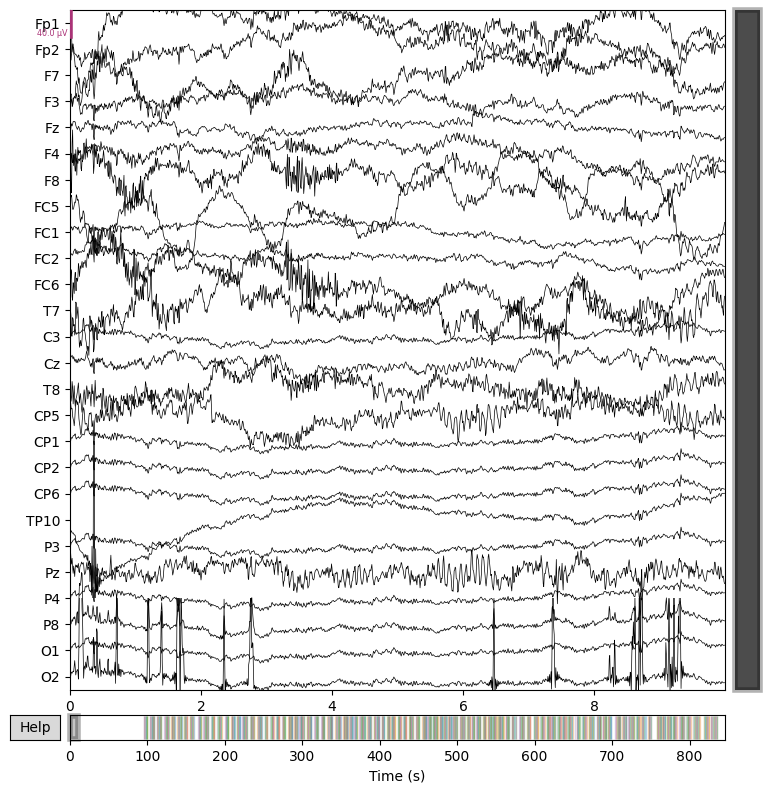

In [7]:

raw_1.filter(l_freq=0.1, h_freq=40)
raw_1.plot(n_channels = 30);

raw_2.filter(l_freq=0.1, h_freq=40)
raw_2.plot(n_channels = 30);

## Epoching data

In [8]:
events_1, _ = mne.events_from_annotations(raw=raw_1)
events_1
unique_triggers_1 = np.unique(events_1[:,2])
unique_triggers_1

events_2, _ = mne.events_from_annotations(raw=raw_2)
events_2
unique_triggers_2 = np.unique(events_2[:,2])
unique_triggers_2

Used Annotations descriptions: [np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3'), np.str_('Stimulus/S 45'), np.str_('Stimulus/S 46'), np.str_('Stimulus/S 47'), np.str_('Stimulus/S 48'), np.str_('Stimulus/S 49'), np.str_('Stimulus/S 50'), np.str_('Stimulus/S 51'), np.str_('Stimulus/S 52'), np.str_('Stimulus/S 53'), np.str_('Stimulus/S 54'), np.str_('Stimulus/S 55'), np.str_('Stimulus/S 56'), np.str_('Stimulus/S 57'), np.str_('Stimulus/S 58'), np.str_('Stimulus/S 59'), np.str_('Stimulus/S 60'), np.str_('Stimulus/S101'), np.str_('Stimulus/S102'), np.str_('Stimulus/S103'), np.str_('Stimulus/S104'), np.str_('Stimulus/S105'), np.str_('Stimulus/S106'), np.str_('Stimulus/S107'), np.str_('Stimulus/S108'), np.str_('Stimulus/S109'), np.str_('Stimulus/S110'), np.str_('Stimulus/S111'), np.str_('Stimulus/S112'), np.str_('Stimulus/S113'), np.str_('Stimulus/S114'), np.str_('Stimulus/S201'), np.str_('Stimulus/S202'), np.str_('Stimulus/S203'), np.str_('Stimulus/S204'), np.str

array([  1,   2,   3,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,
        55,  56,  57,  58,  59,  60, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 111, 112, 113, 114, 201, 202, 203, 204, 205, 206,
       207, 208, 209, 210, 211, 212, 213, 214, 215])

Setting up an event_id dictionary

/tmp/ipykernel_906/4256439367.py:52: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  mne.viz.plot_events(events_1, event_id=event_id);


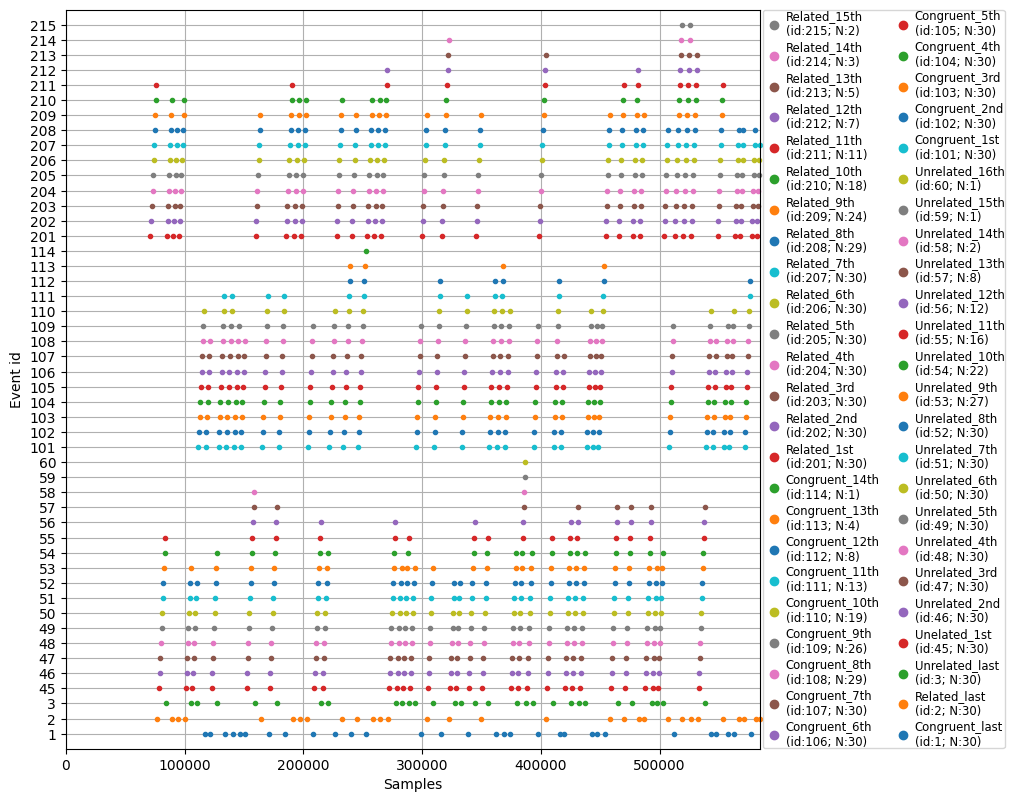

/tmp/ipykernel_906/4256439367.py:53: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  mne.viz.plot_events(events_2, event_id=event_id);


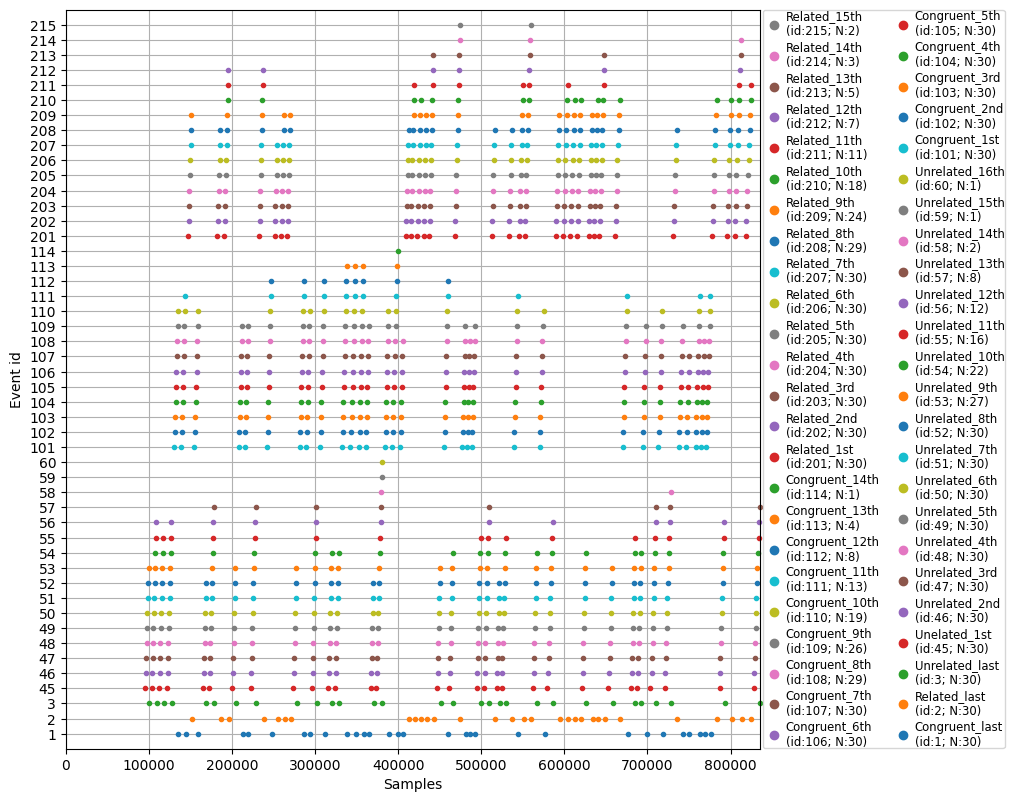

In [9]:
event_id = {
    "Congruent_last": 1,
    "Related_last": 2,
    "Unrelated_last": 3,
    "Congruent_1st": 101,
    "Congruent_2nd": 102,
    "Congruent_3rd": 103,
    "Congruent_4th": 104,
    "Congruent_5th": 105,
    "Congruent_6th": 106,
    "Congruent_7th": 107,
    "Congruent_8th": 108,
    "Congruent_9th": 109,
    "Congruent_10th": 110,
    "Congruent_11th": 111,
    "Congruent_12th": 112,
    "Congruent_13th": 113,
    "Congruent_14th": 114,
    "Related_1st": 201,
    "Related_2nd": 202,
    "Related_3rd": 203,
    "Related_4th": 204,
    "Related_5th": 205,
    "Related_6th": 206,
    "Related_7th": 207,
    "Related_8th": 208,
    "Related_9th": 209,
    "Related_10th": 210,
    "Related_11th": 211,
    "Related_12th": 212,
    "Related_13th": 213,
    "Related_14th": 214,
    "Related_15th": 215,
    "Unelated_1st": 45,
    "Unrelated_2nd": 46,
    "Unrelated_3rd": 47,
    "Unrelated_4th": 48,
    "Unrelated_5th": 49,
    "Unrelated_6th": 50,
    "Unrelated_7th": 51,
    "Unrelated_8th": 52,
    "Unrelated_9th": 53,
    "Unrelated_10th": 54,
    "Unrelated_11th": 55,
    "Unrelated_12th": 56,
    "Unrelated_13th": 57,
    "Unrelated_14th": 58,
    "Unrelated_15th": 59,
    "Unrelated_16th": 60
}

mne.viz.plot_events(events_1, event_id=event_id);
mne.viz.plot_events(events_2, event_id=event_id);


Setting time-window and reject-criterion

In [10]:
tmin, tmax = -0.2, 0.8

reject = {'eeg': 150e-6}

picks = ['eeg']

epochs_1 = mne.Epochs(raw = raw_1, events = events_1, reject = reject, tmin = tmin, tmax = tmax, baseline = (-0.2,0), preload=True)

epochs_2 = mne.Epochs(raw = raw_2, events = events_2, reject = reject, tmin = tmin, tmax = tmax, baseline = (-0.2,0), preload=True)

Not setting metadata
1038 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1038 events and 1001 original time points ...
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'TP10']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'TP10']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'TP10']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based

Downsampling to 250 Hz

In [11]:
epochs_1 = epochs_1.resample(sfreq=250)
epochs_1

epochs_2 = epochs_2.resample(sfreq=250)
epochs_2

<Epochs | 934 events (all good), -0.2 – 0.796 s (baseline -0.2 – 0 s), ~46.4 MiB, data loaded,
 '1': 29
 '2': 27
 '3': 28
 '45': 24
 '46': 24
 '47': 24
 '48': 26
 '49': 27
 '50': 28
 '51': 28
 and 38 more events ...>

Making a plot of brain responses

Not setting metadata
805 matching events found
No baseline correction applied
0 projection items activated


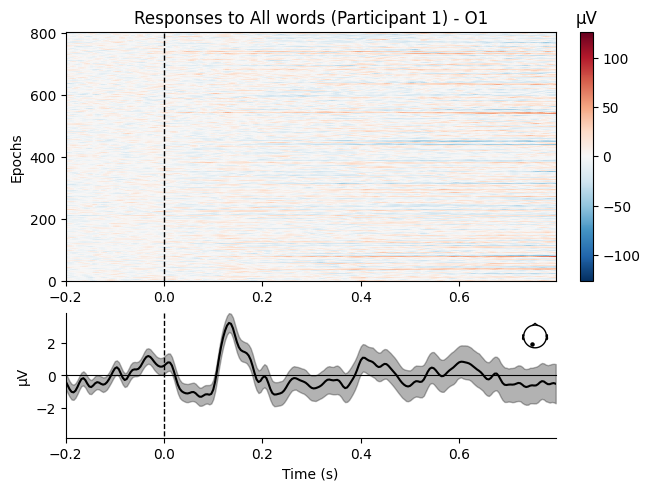

Not setting metadata
934 matching events found
No baseline correction applied
0 projection items activated


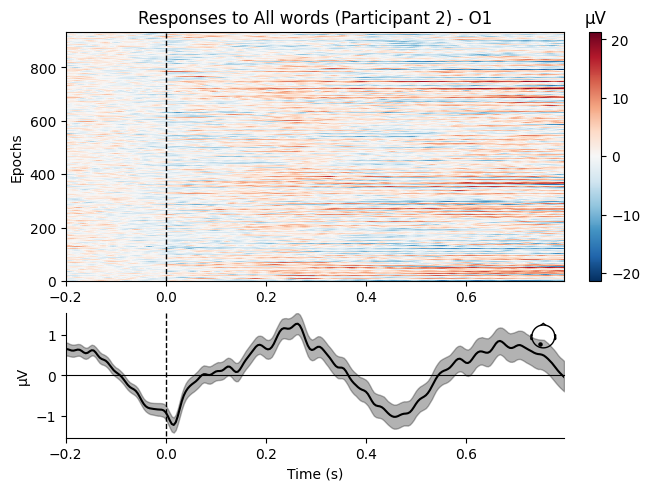

Not setting metadata
805 matching events found
No baseline correction applied
0 projection items activated


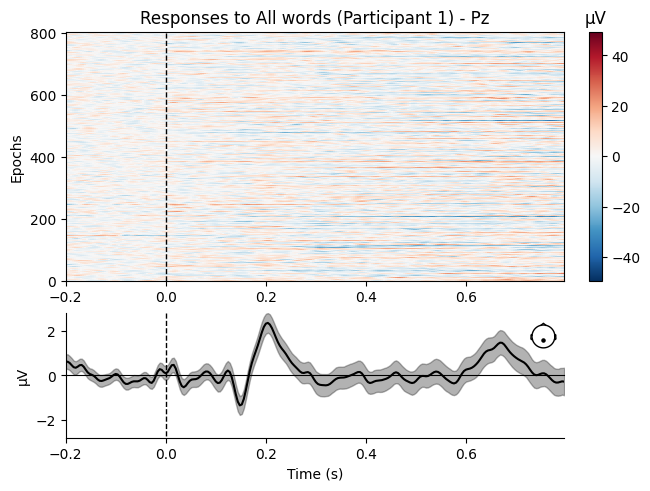

Not setting metadata
934 matching events found
No baseline correction applied
0 projection items activated


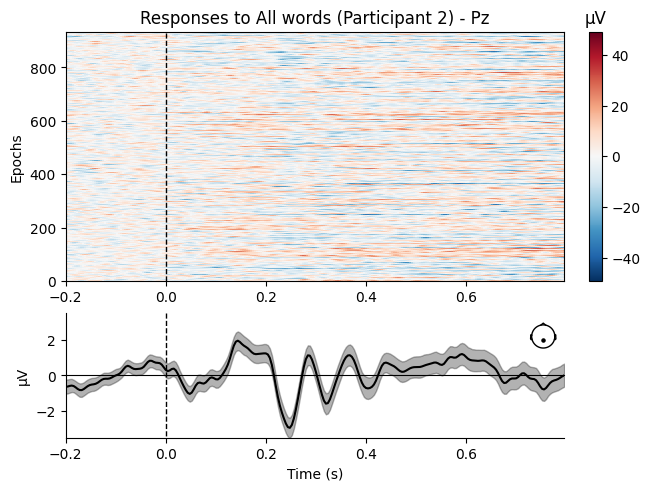

No projector specified for this dataset. Please consider the method self.add_proj.


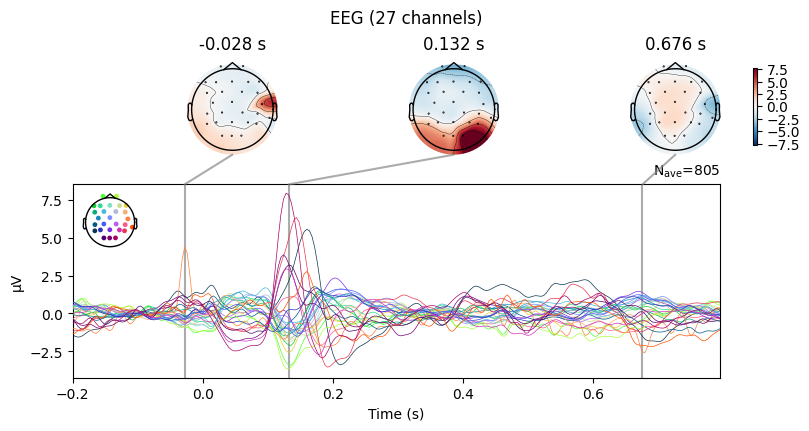

No projector specified for this dataset. Please consider the method self.add_proj.


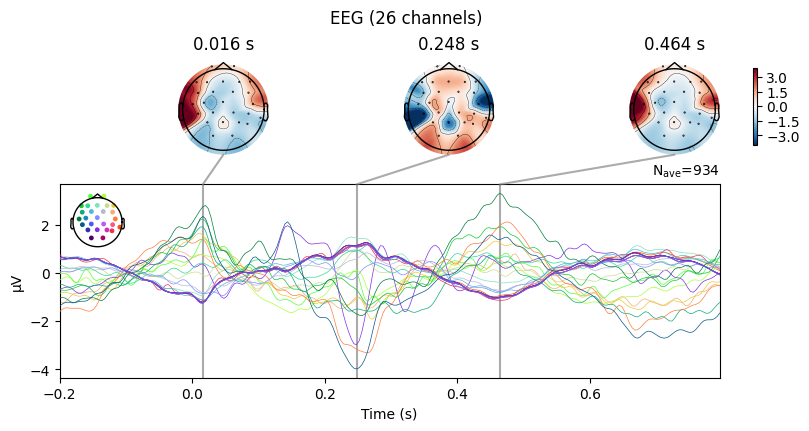

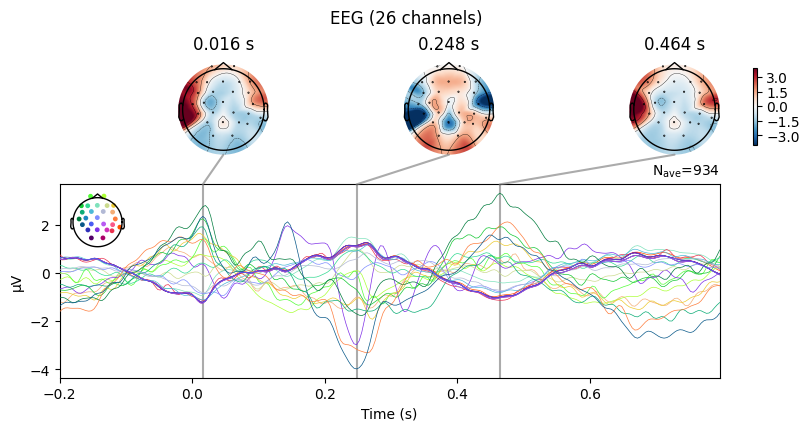

In [12]:
# Sanity check - all words

epochs_1.plot_image(picks=['O1'], title = "Responses to All words (Participant 1) - O1");

epochs_2.plot_image(picks=['O1'], title = "Responses to All words (Participant 2) - O1");

epochs_1.plot_image(picks=['Pz'], title = "Responses to All words (Participant 1) - Pz");

epochs_2.plot_image(picks=['Pz'], title = "Responses to All words (Participant 2) - Pz");

evoked_words_1 = epochs_1.average()
evoked_words_2 = epochs_2.average()

evoked_words_1.plot_joint()
evoked_words_2.plot_joint()

Not setting metadata
27 matching events found
No baseline correction applied
0 projection items activated


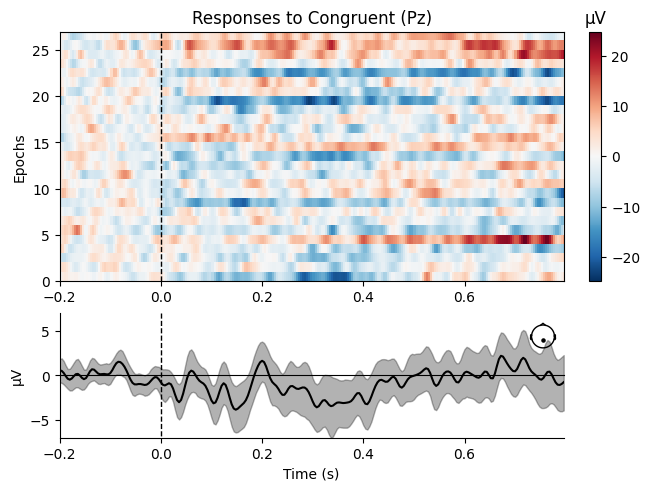

Not setting metadata
27 matching events found
No baseline correction applied
0 projection items activated


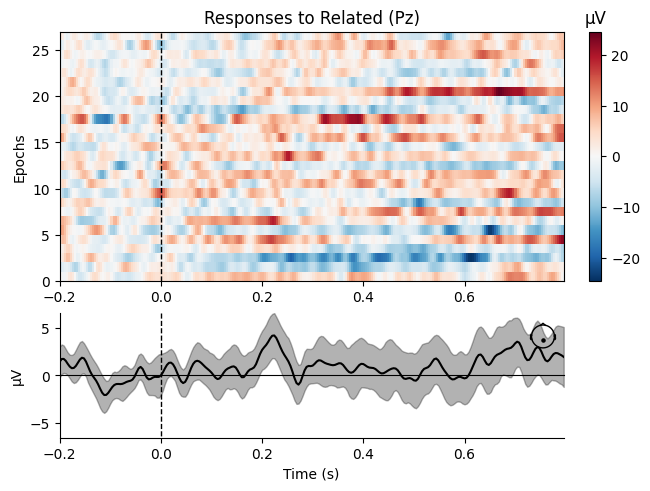

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated


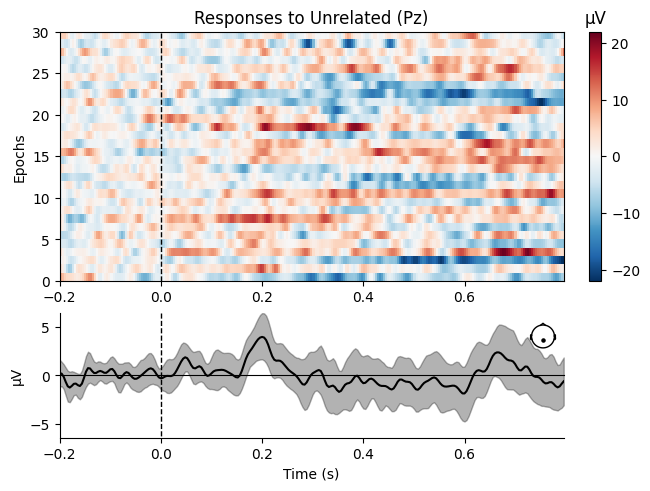

Not setting metadata
29 matching events found
No baseline correction applied
0 projection items activated


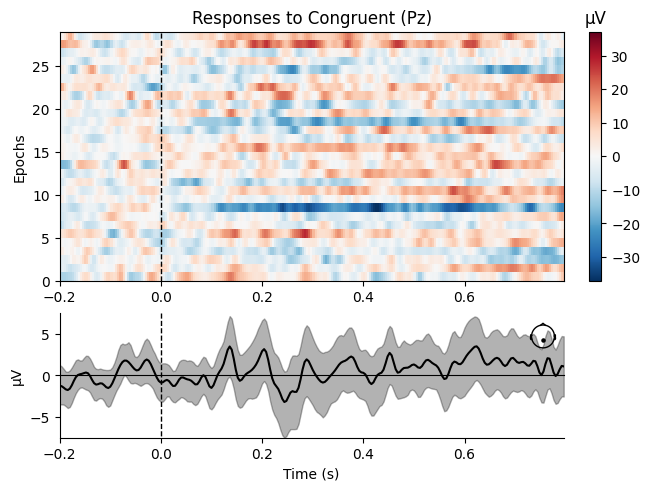

Not setting metadata
27 matching events found
No baseline correction applied
0 projection items activated


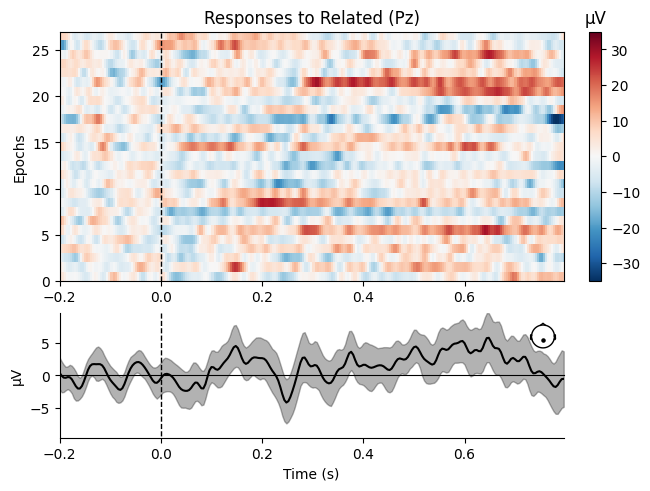

Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated


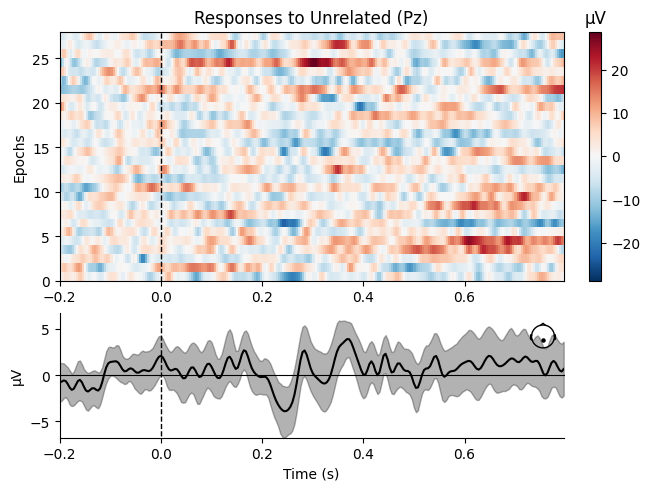

In [13]:
congruent_epochs_1 = epochs_1['1']
related_epochs_1 = epochs_1['2']
unrelated_epochs_1 = epochs_1['3']

congruent_epochs_1.plot_image(picks=['Pz'], title = "Responses to Congruent (Pz)");
related_epochs_1.plot_image(picks=['Pz'], title = "Responses to Related (Pz)");
unrelated_epochs_1.plot_image(picks=['Pz'], title = "Responses to Unrelated (Pz)");

congruent_epochs_2 = epochs_2['1']
related_epochs_2 = epochs_2['2']
unrelated_epochs_2 = epochs_2['3']

congruent_epochs_2.plot_image(picks=['Pz'], title = "Responses to Congruent (Pz)");
related_epochs_2.plot_image(picks=['Pz'], title = "Responses to Related (Pz)");
unrelated_epochs_2.plot_image(picks=['Pz'], title = "Responses to Unrelated (Pz)");


Creating evoked variables

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


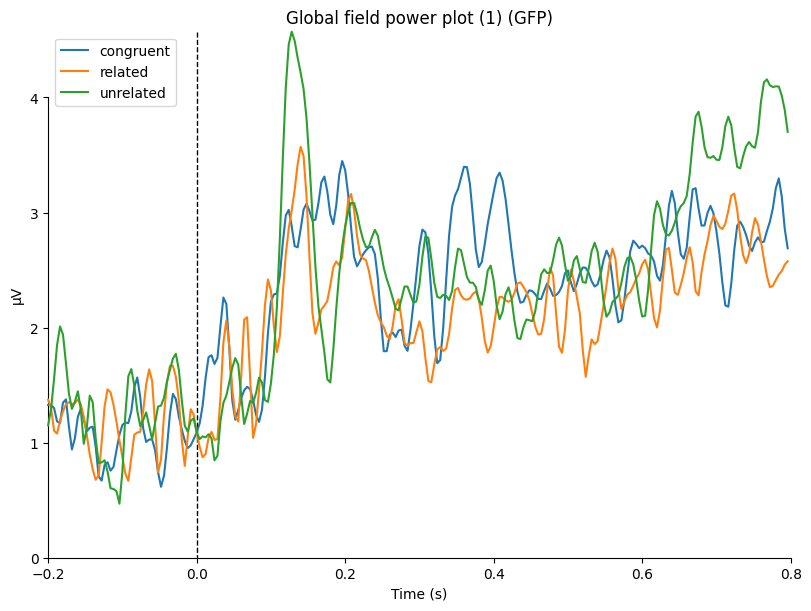

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


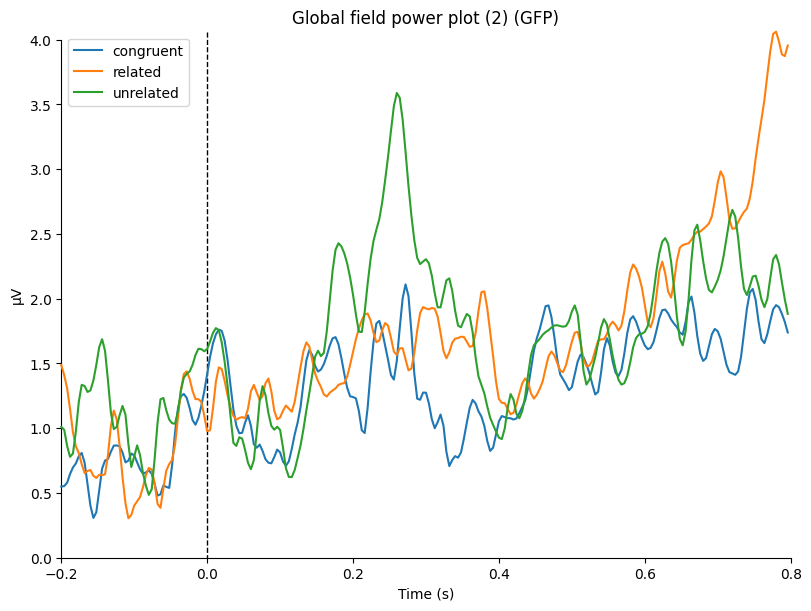

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


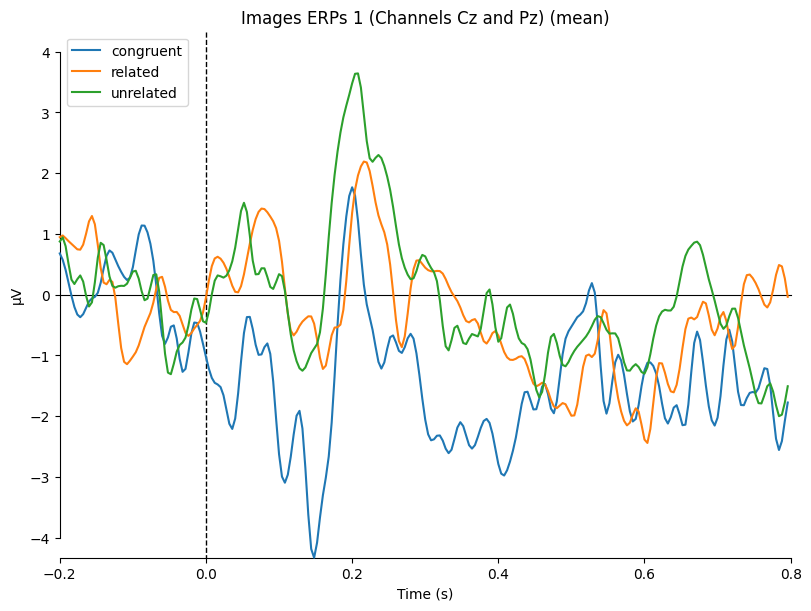

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


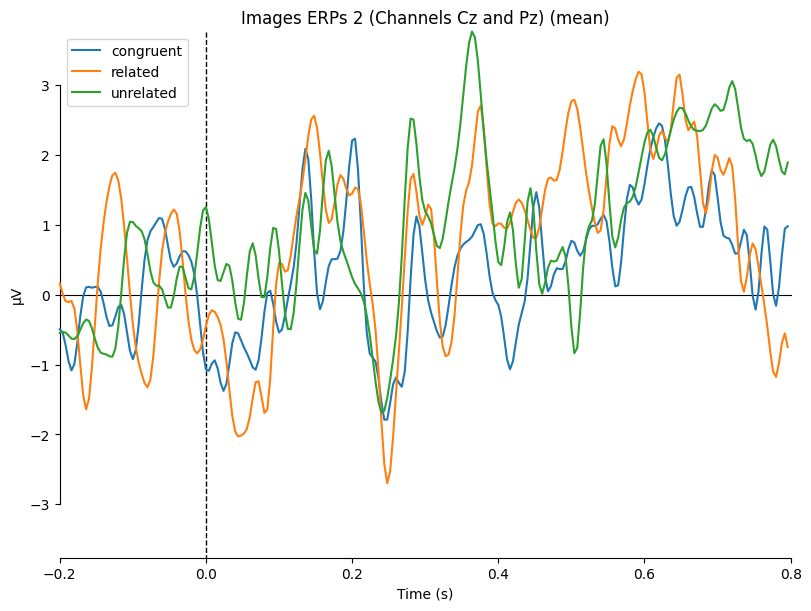

[<Figure size 800x600 with 1 Axes>]

In [14]:
# creating evoked variables

congruent_1 = congruent_epochs_1.average()
related_1 = related_epochs_1.average()
unrelated_1 = unrelated_epochs_1.average()

congruent_2 = congruent_epochs_2.average()
related_2 = related_epochs_2.average()
unrelated_2 = unrelated_epochs_2.average()

# plotting

mne.viz.plot_compare_evokeds(
        {"congruent": congruent_1,
        "related": related_1,
        "unrelated": unrelated_1}, title="Global field power plot (1)", legend='upper left')

mne.viz.plot_compare_evokeds(
        {"congruent": congruent_2,
        "related": related_2,
        "unrelated": unrelated_2}, title="Global field power plot (2)", legend='upper left')


mne.viz.plot_compare_evokeds(
         {"congruent": congruent_1,
        "related": related_1,
        "unrelated": unrelated_1}, picks = ["Pz", "Cz"] , 
        combine="mean", title="Images ERPs 1 (Channels Cz and Pz)", legend='upper left')

mne.viz.plot_compare_evokeds(
         {"congruent": congruent_2,
        "related": related_2,
        "unrelated": unrelated_2}, picks = ["Pz", "Cz"] , 
        combine="mean", title="Images ERPs 2 (Channels Cz and Pz)", legend='upper left')

No projector specified for this dataset. Please consider the method self.add_proj.


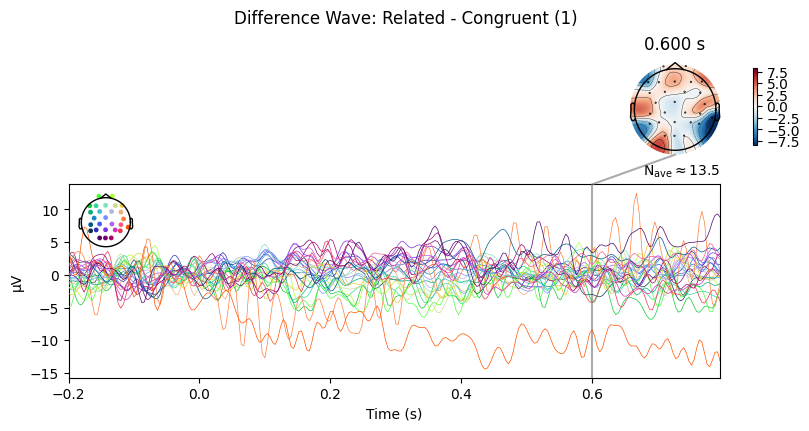

No projector specified for this dataset. Please consider the method self.add_proj.


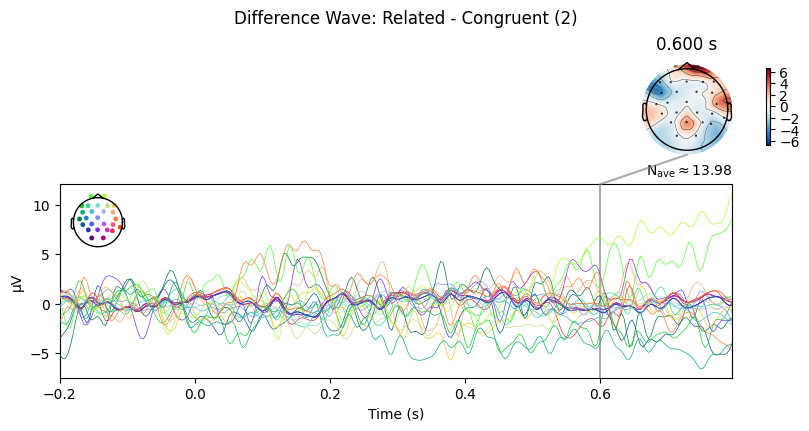

No projector specified for this dataset. Please consider the method self.add_proj.


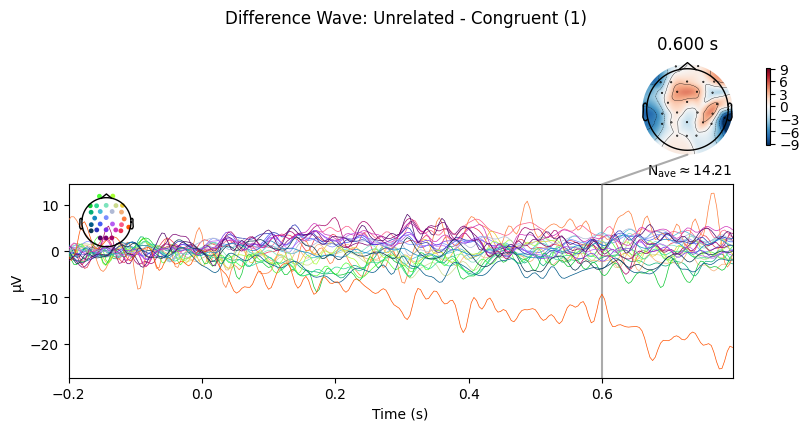

No projector specified for this dataset. Please consider the method self.add_proj.


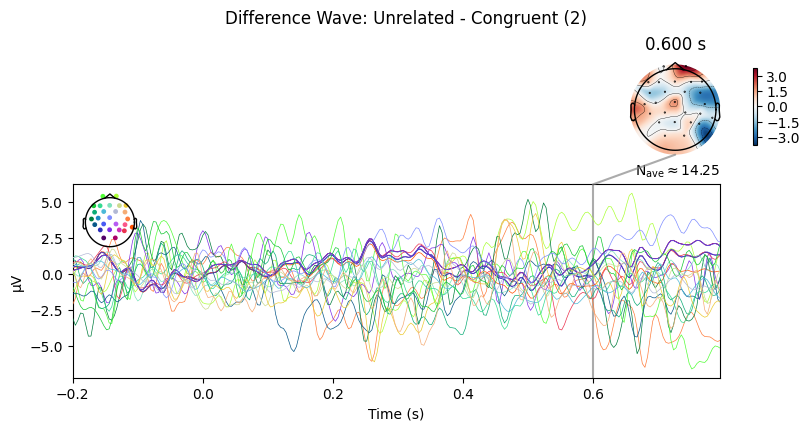

In [15]:
# Create the Difference Wave
difference_related_1 = mne.combine_evoked([related_1, congruent_1], 
                               weights=[1, -1])

difference_related_2 = mne.combine_evoked([related_2, congruent_2], 
                               weights=[1, -1])

difference_unrelated_1 = mne.combine_evoked([unrelated_1, congruent_1], 
                               weights=[1, -1])

difference_unrelated_2 = mne.combine_evoked([unrelated_2, congruent_2], 
                               weights=[1, -1])
# Plot it
difference_related_1.plot_joint(times=[0.6], title="Difference Wave: Related - Congruent (1)");
difference_related_2.plot_joint(times=[0.6], title="Difference Wave: Related - Congruent (2)");
difference_unrelated_1.plot_joint(times=[0.6], title="Difference Wave: Unrelated - Congruent (1)");
difference_unrelated_2.plot_joint(times=[0.6], title="Difference Wave: Unrelated - Congruent (2)");

# Analysis

## Subject level windowed mean analysis

### N400

In [16]:
# chosen channels
picks = ["Fz", "Cz", "Pz"]

# time window for windowed mean in seconds 
tmin = 0.3
tmax = 0.5

# extract the data
data_c1 = congruent_epochs_1.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_r1= related_epochs_1.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_u1 = unrelated_epochs_1.get_data(picks = picks, tmin = tmin, tmax = tmax)

data_c2 = congruent_epochs_2.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_r2= related_epochs_2.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_u2 = unrelated_epochs_2.get_data(picks = picks, tmin = tmin, tmax = tmax)

# averaging over the time window and channels
data_c1_mean = np.mean(data_c1, axis=(1,2))
data_r1_mean = np.mean(data_r1, axis=(1,2))
data_u1_mean = np.mean(data_u1, axis=(1,2))

data_c2_mean = np.mean(data_c2, axis=(1,2))
data_r2_mean = np.mean(data_r2, axis=(1,2))
data_u2_mean = np.mean(data_u2, axis=(1,2))

print(data_c1_mean.shape)
print(data_r1_mean.shape)
print(data_u1_mean.shape)
print(data_c2_mean.shape)
print(data_r2_mean.shape)
print(data_u2_mean.shape)

(27,)
(27,)
(30,)
(29,)
(27,)
(28,)


Anova

In [17]:
from scipy import stats

stat_c1, p_c1 = stats.shapiro(data_c1_mean)
stat_r1, p_r1 = stats.shapiro(data_r1_mean)
stat_u1, p_u1 = stats.shapiro(data_u1_mean)

stat_c2, p_c2 = stats.shapiro(data_c2_mean)
stat_r2, p_r2 = stats.shapiro(data_r2_mean)
stat_u2, p_u2 = stats.shapiro(data_u2_mean)

print(f'Congruent 1: statistic={stat_c1:.3f}, p={p_c1:.3f}')
print(f'Related 1: statistic={stat_r1:.3f}, p = {p_r1:.3f}')
print(f'Unrelated 1: statistic={stat_u1:.3f}, p = {p_u1:.3f}')

print(f'Congruent 2: statistic={stat_c2:.3f}, p={p_c2:.3f}')
print(f'Related 2: statistic={stat_r2:.3f}, p = {p_r2:.3f}')
print(f'Unrelated 2: statistic={stat_u2:.3f}, p = {p_u2:.3f}')

Congruent 1: statistic=0.941, p=0.125
Related 1: statistic=0.938, p = 0.106
Unrelated 1: statistic=0.925, p = 0.035
Congruent 2: statistic=0.941, p=0.105
Related 2: statistic=0.956, p = 0.306
Unrelated 2: statistic=0.965, p = 0.465


The Shapiro-Wilk tests on all of the conditions show that the data is normal (all *p*s > 0.05).

In [18]:
levene_stat_1, p_levene_1 = stats.levene(data_c1_mean, data_r1_mean, data_u1_mean)

levene_stat_2, p_levene_2 = stats.levene(data_c2_mean, data_r2_mean, data_u2_mean)


print(f"Participant 1: statistic={levene_stat_1:.3f}, {p_levene_1:.3f}")
print(f"Participant 2: statistic={levene_stat_2:.3f}, {p_levene_2:.3f}")

Participant 1: statistic=1.415, 0.249
Participant 2: statistic=0.481, 0.620


The Levene's test for homogeneity of variance across 3 conditions shows that the assumption of homoscedasticity is not violated for both participants (both *p*s > 0.05). 

Considering that for both participants the data doesn't violate the assumptions of normality and homogeneity of variance, we will use a one-way ANOVA. 

In [19]:
F_1, p_1 = stats.f_oneway(data_c1_mean, data_r1_mean, data_u1_mean)

F_2, p_2 = stats.f_oneway(data_c2_mean, data_r2_mean, data_u2_mean)

print(f'Participant 1: F={F_1:.3f}, p={p_1:.3f}')
print(f'Participant 2: F={F_2:.3f}, p={p_2:.3f}')

Participant 1: F=0.380, p=0.685
Participant 2: F=0.321, p=0.727


The one-way ANOVA shows no difference between N400 amplitudes of all conditions for both participants (both *p*s > 0.5)

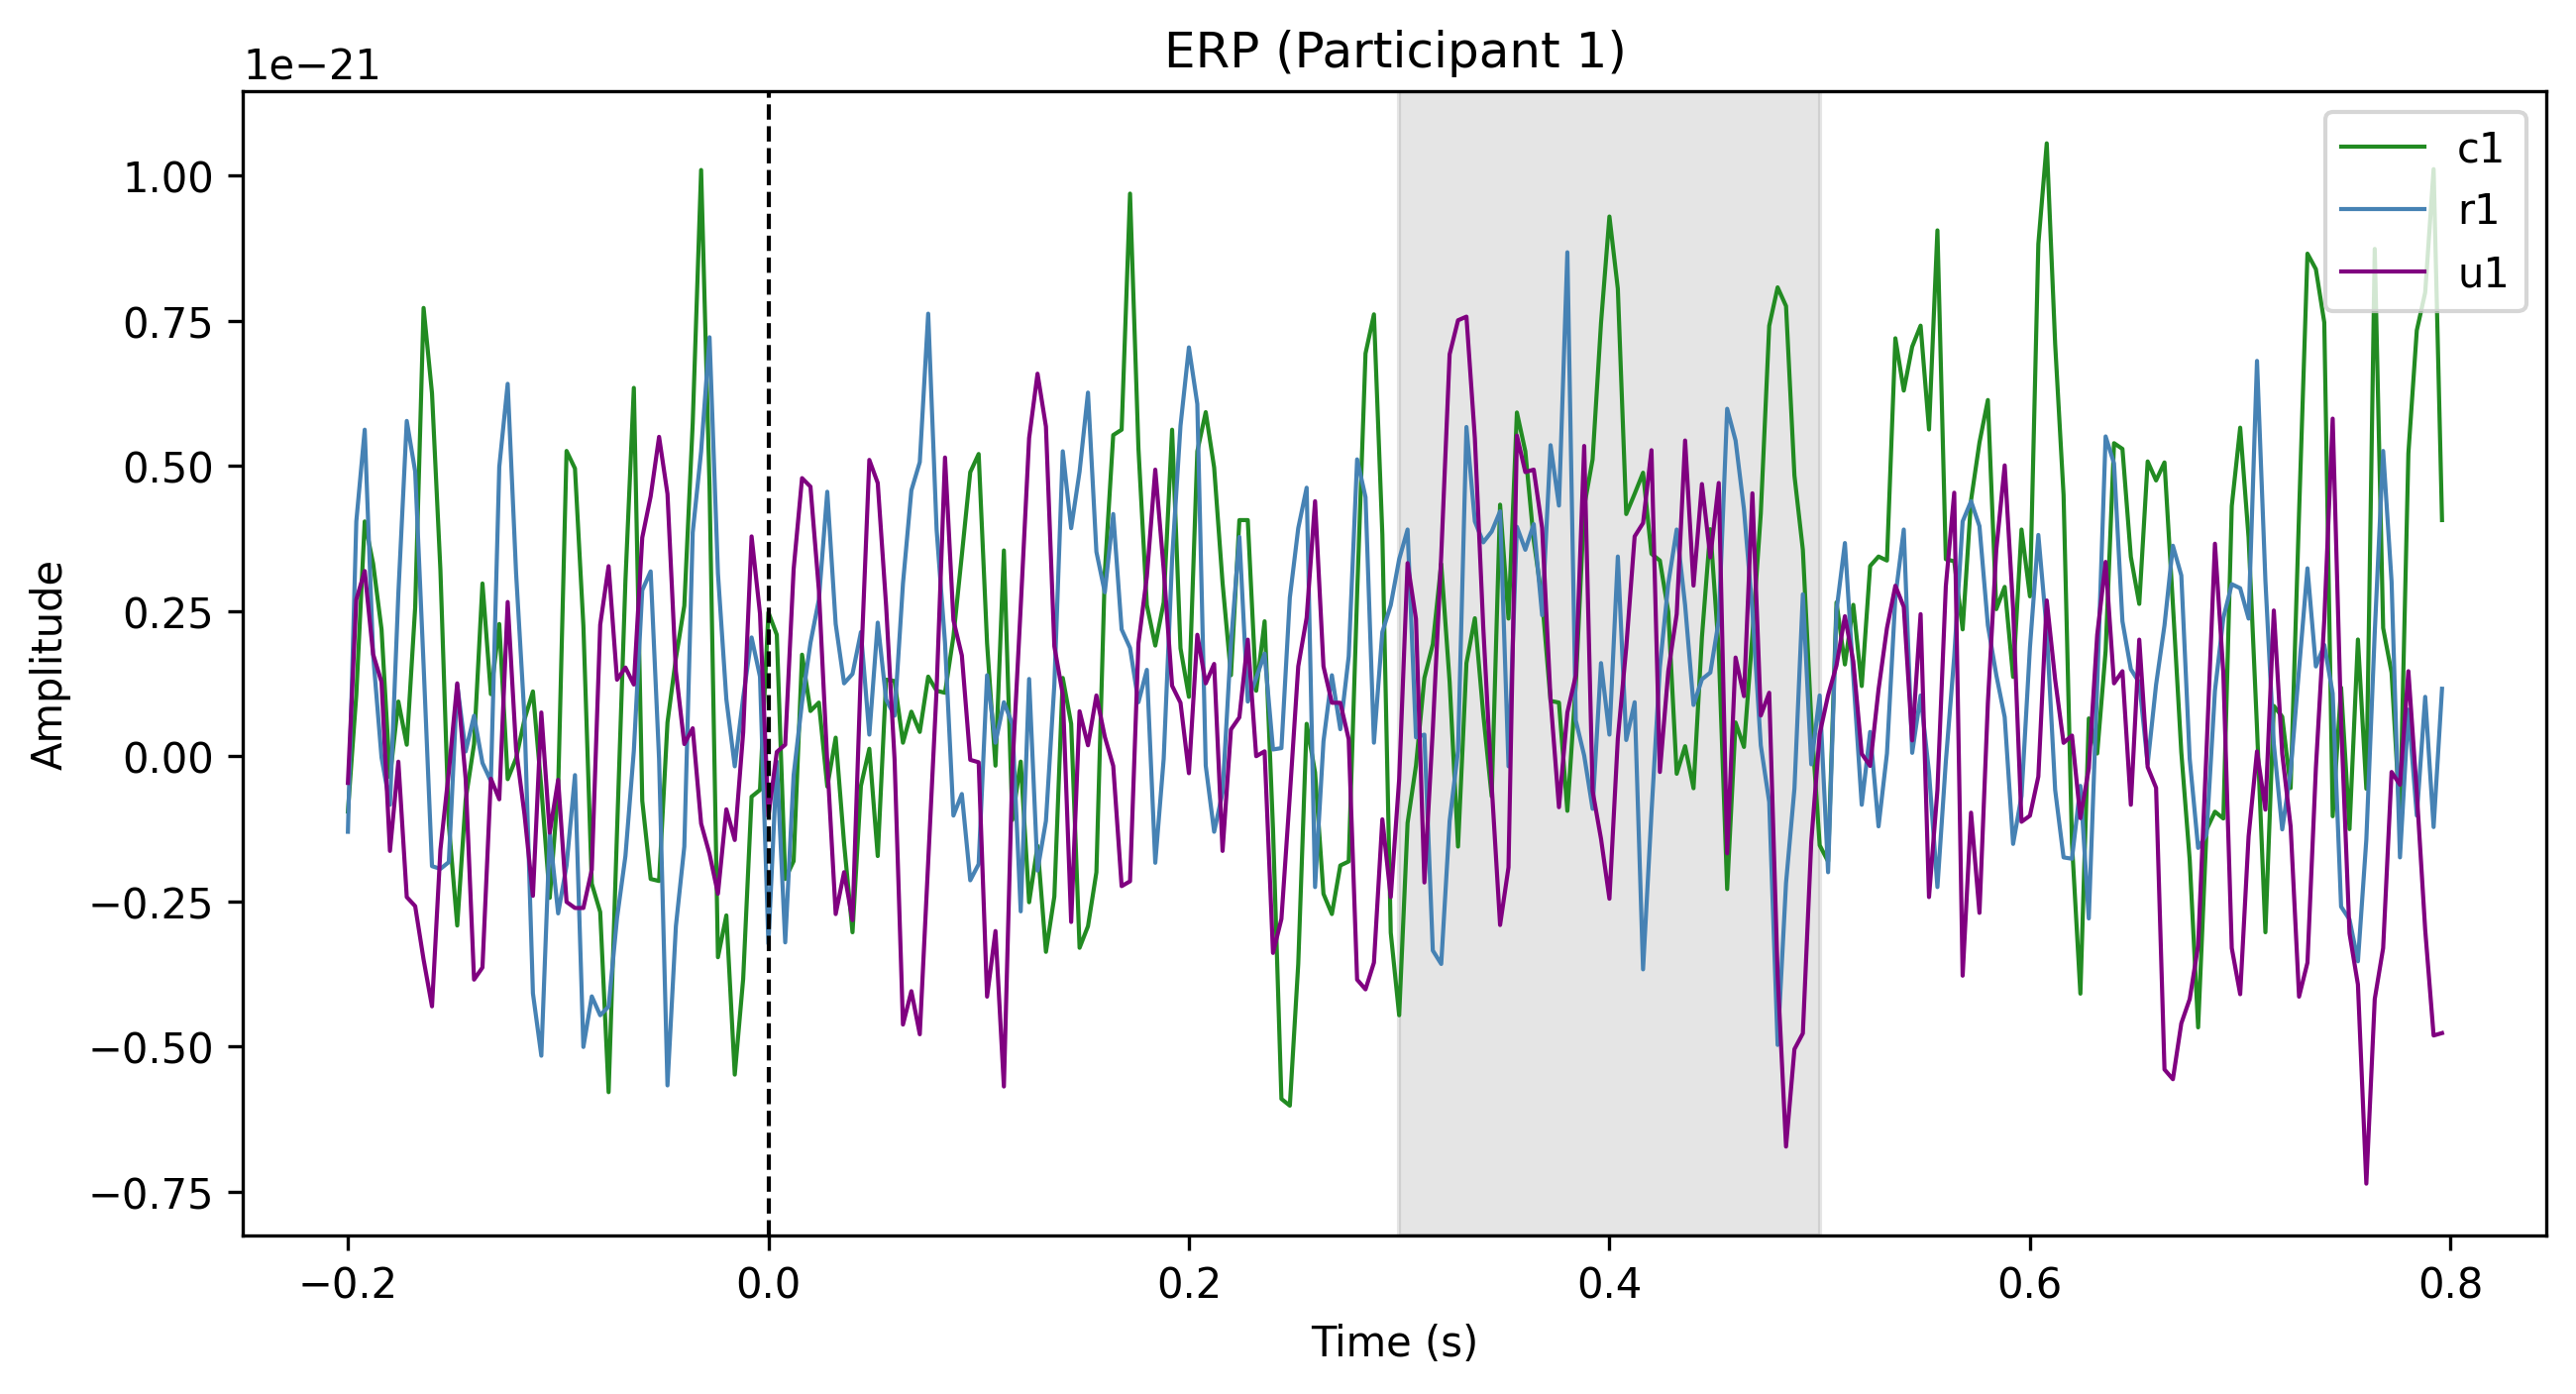

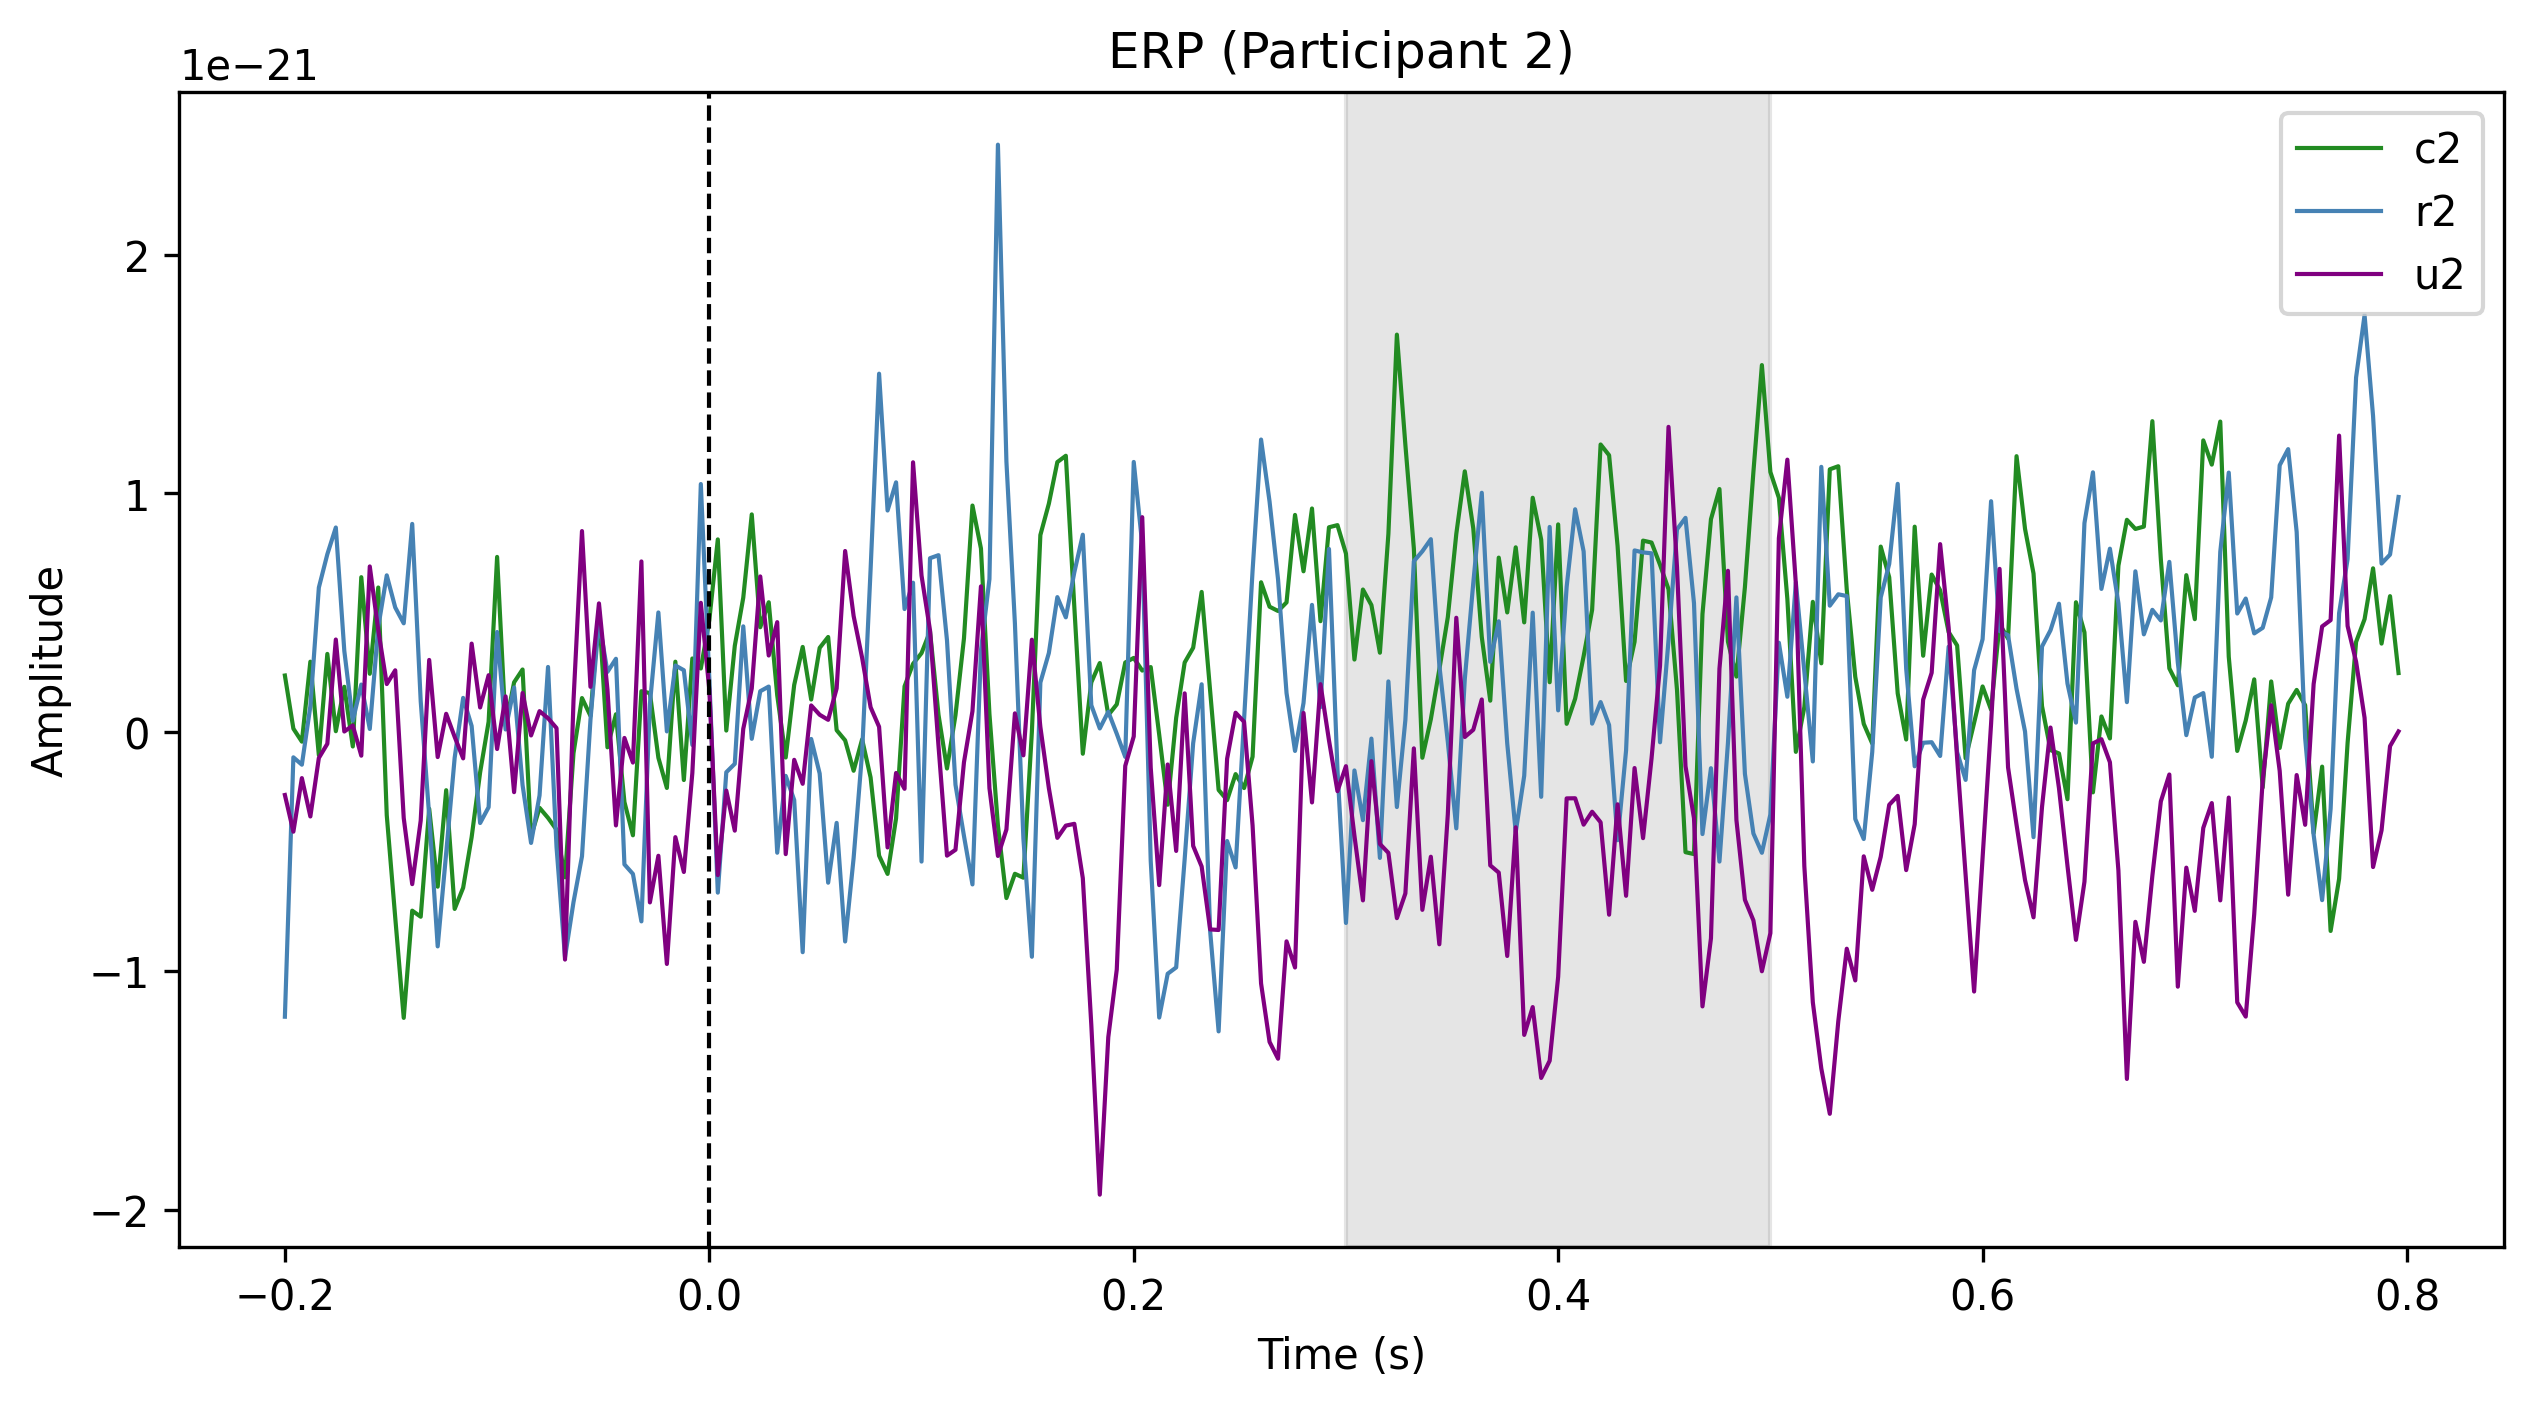

In [20]:
plot_data_c1 = congruent_epochs_1.get_data(copy = True).mean(axis=(0, 1))
plot_data_r1= related_epochs_1.get_data(copy = True).mean(axis=(0, 1))
plot_data_u1 = unrelated_epochs_1.get_data(copy = True).mean(axis=(0, 1))

plot_data_c2 = congruent_epochs_2.get_data(copy = True).mean(axis=(0, 1))
plot_data_r2= related_epochs_2.get_data(copy = True).mean(axis=(0, 1))
plot_data_u2 = unrelated_epochs_2.get_data(copy = True).mean(axis=(0, 1))

times = congruent_epochs_1.times

fig, ax = plt.subplots(1, figsize=(10, 5), dpi=300)

# plot the time window
ax.axvspan(tmin, tmax, color="grey", alpha=0.2)

# plot the time course
ax.plot(times, plot_data_c1.T, label="c1", linewidth=1, color="forestgreen")
ax.plot(times, plot_data_r1.T, label="r1", linewidth=1, color="steelblue")
ax.plot(times, plot_data_u1.T, label="u1", linewidth=1, color="purple")

# vertical line at 0
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)

ax.set(xlabel="Time (s)", ylabel="Amplitude", title="ERP (Participant 1)")
ax.legend(loc = "upper right")

fig, ax = plt.subplots(1, figsize=(10, 5), dpi=300)

# plot the time window
ax.axvspan(tmin, tmax, color="grey", alpha=0.2)

# plot the time course
ax.plot(times, plot_data_c2.T, label="c2", linewidth=1, color="forestgreen")
ax.plot(times, plot_data_r2.T, label="r2", linewidth=1, color="steelblue")
ax.plot(times, plot_data_u2.T, label="u2", linewidth=1, color="purple")

# vertical line at 0
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)

ax.set(xlabel="Time (s)", ylabel="Amplitude", title="ERP (Participant 2)")
ax.legend(loc = "upper right")

### P600

In [21]:
# chosen channels
picks = ["Fz", "Cz", "Pz", "CP1", "CP2", "P3", "P4"]

# time window for windowed mean in seconds 
tmin = 0.5
tmax = 0.8

# extract the data
data_c1 = congruent_epochs_1.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_r1= related_epochs_1.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_u1 = unrelated_epochs_1.get_data(picks = picks, tmin = tmin, tmax = tmax)

data_c2 = congruent_epochs_2.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_r2= related_epochs_2.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_u2 = unrelated_epochs_2.get_data(picks = picks, tmin = tmin, tmax = tmax)

# averaging over the time window and channels
data_c1_mean = np.mean(data_c1, axis=(1,2))
data_r1_mean = np.mean(data_r1, axis=(1,2))
data_u1_mean = np.mean(data_u1, axis=(1,2))

data_c2_mean = np.mean(data_c2, axis=(1,2))
data_r2_mean = np.mean(data_r2, axis=(1,2))
data_u2_mean = np.mean(data_u2, axis=(1,2))

print(data_c1_mean.shape)
print(data_r1_mean.shape)
print(data_u1_mean.shape)
print(data_c2_mean.shape)
print(data_r2_mean.shape)
print(data_u2_mean.shape)

(27,)
(27,)
(30,)
(29,)
(27,)
(28,)


In [22]:
stat_c1, p_c1 = stats.shapiro(data_c1_mean)
stat_r1, p_r1 = stats.shapiro(data_r1_mean)
stat_u1, p_u1 = stats.shapiro(data_u1_mean)

stat_c2, p_c2 = stats.shapiro(data_c2_mean)
stat_r2, p_r2 = stats.shapiro(data_r2_mean)
stat_u2, p_u2 = stats.shapiro(data_u2_mean)

print(f'Congruent 1: statistic={stat_c1:.3f}, p={p_c1:.3f}')
print(f'Related 1: statistic={stat_r1:.3f}, p = {p_r1:.3f}')
print(f'Unrelated 1: statistic={stat_u1:.3f}, p = {p_u1:.3f}')

print(f'Congruent 2: statistic={stat_c2:.3f}, p={p_c2:.3f}')
print(f'Related 2: statistic={stat_r2:.3f}, p = {p_r2:.3f}')
print(f'Unrelated 2: statistic={stat_u2:.3f}, p = {p_u2:.3f}')

Congruent 1: statistic=0.959, p=0.360
Related 1: statistic=0.991, p = 0.998
Unrelated 1: statistic=0.976, p = 0.722
Congruent 2: statistic=0.960, p=0.326
Related 2: statistic=0.983, p = 0.930
Unrelated 2: statistic=0.977, p = 0.761


The Shapiro-Wilk tests on all of the conditions show that most of the data is normal (all *p*s > 0.05, except related condition for 2nd participant).

In [23]:
levene_stat_1, p_levene_1 = stats.levene(data_c1_mean, data_r1_mean, data_u1_mean)

levene_stat_2, p_levene_2 = stats.levene(data_c2_mean, data_r2_mean, data_u2_mean)


print(f"Participant 1: statistic={levene_stat_1:.3f}, {p_levene_1:.3f}")
print(f"Participant 2: statistic={levene_stat_2:.3f}, {p_levene_2:.3f}")

Participant 1: statistic=0.548, 0.580
Participant 2: statistic=0.823, 0.443


The Levene's test for homogeneity of variance across 3 conditions shows that the assumption of homoscedasticity is not violated for both participants (both *p*s > 0.2). 

Considering that for both participants the data doesn't violate the assumptions of normality and homogeneity of variance, we will use a one-way ANOVA. 

In [24]:
F_1, p_1 = stats.f_oneway(data_c1_mean, data_r1_mean, data_u1_mean)

F_2, p_2 = stats.f_oneway(data_c2_mean, data_r2_mean, data_u2_mean)

print(f'Participant 1: F={F_1:.3f}, p={p_1:.3f}')
print(f'Participant 2: F={F_2:.3f}, p={p_2:.3f}')

Participant 1: F=1.106, p=0.336
Participant 2: F=0.594, p=0.555


The one-way ANOVA shows no difference in P600 amplitude across all conditions for both participants (both *p*s > 0.1).

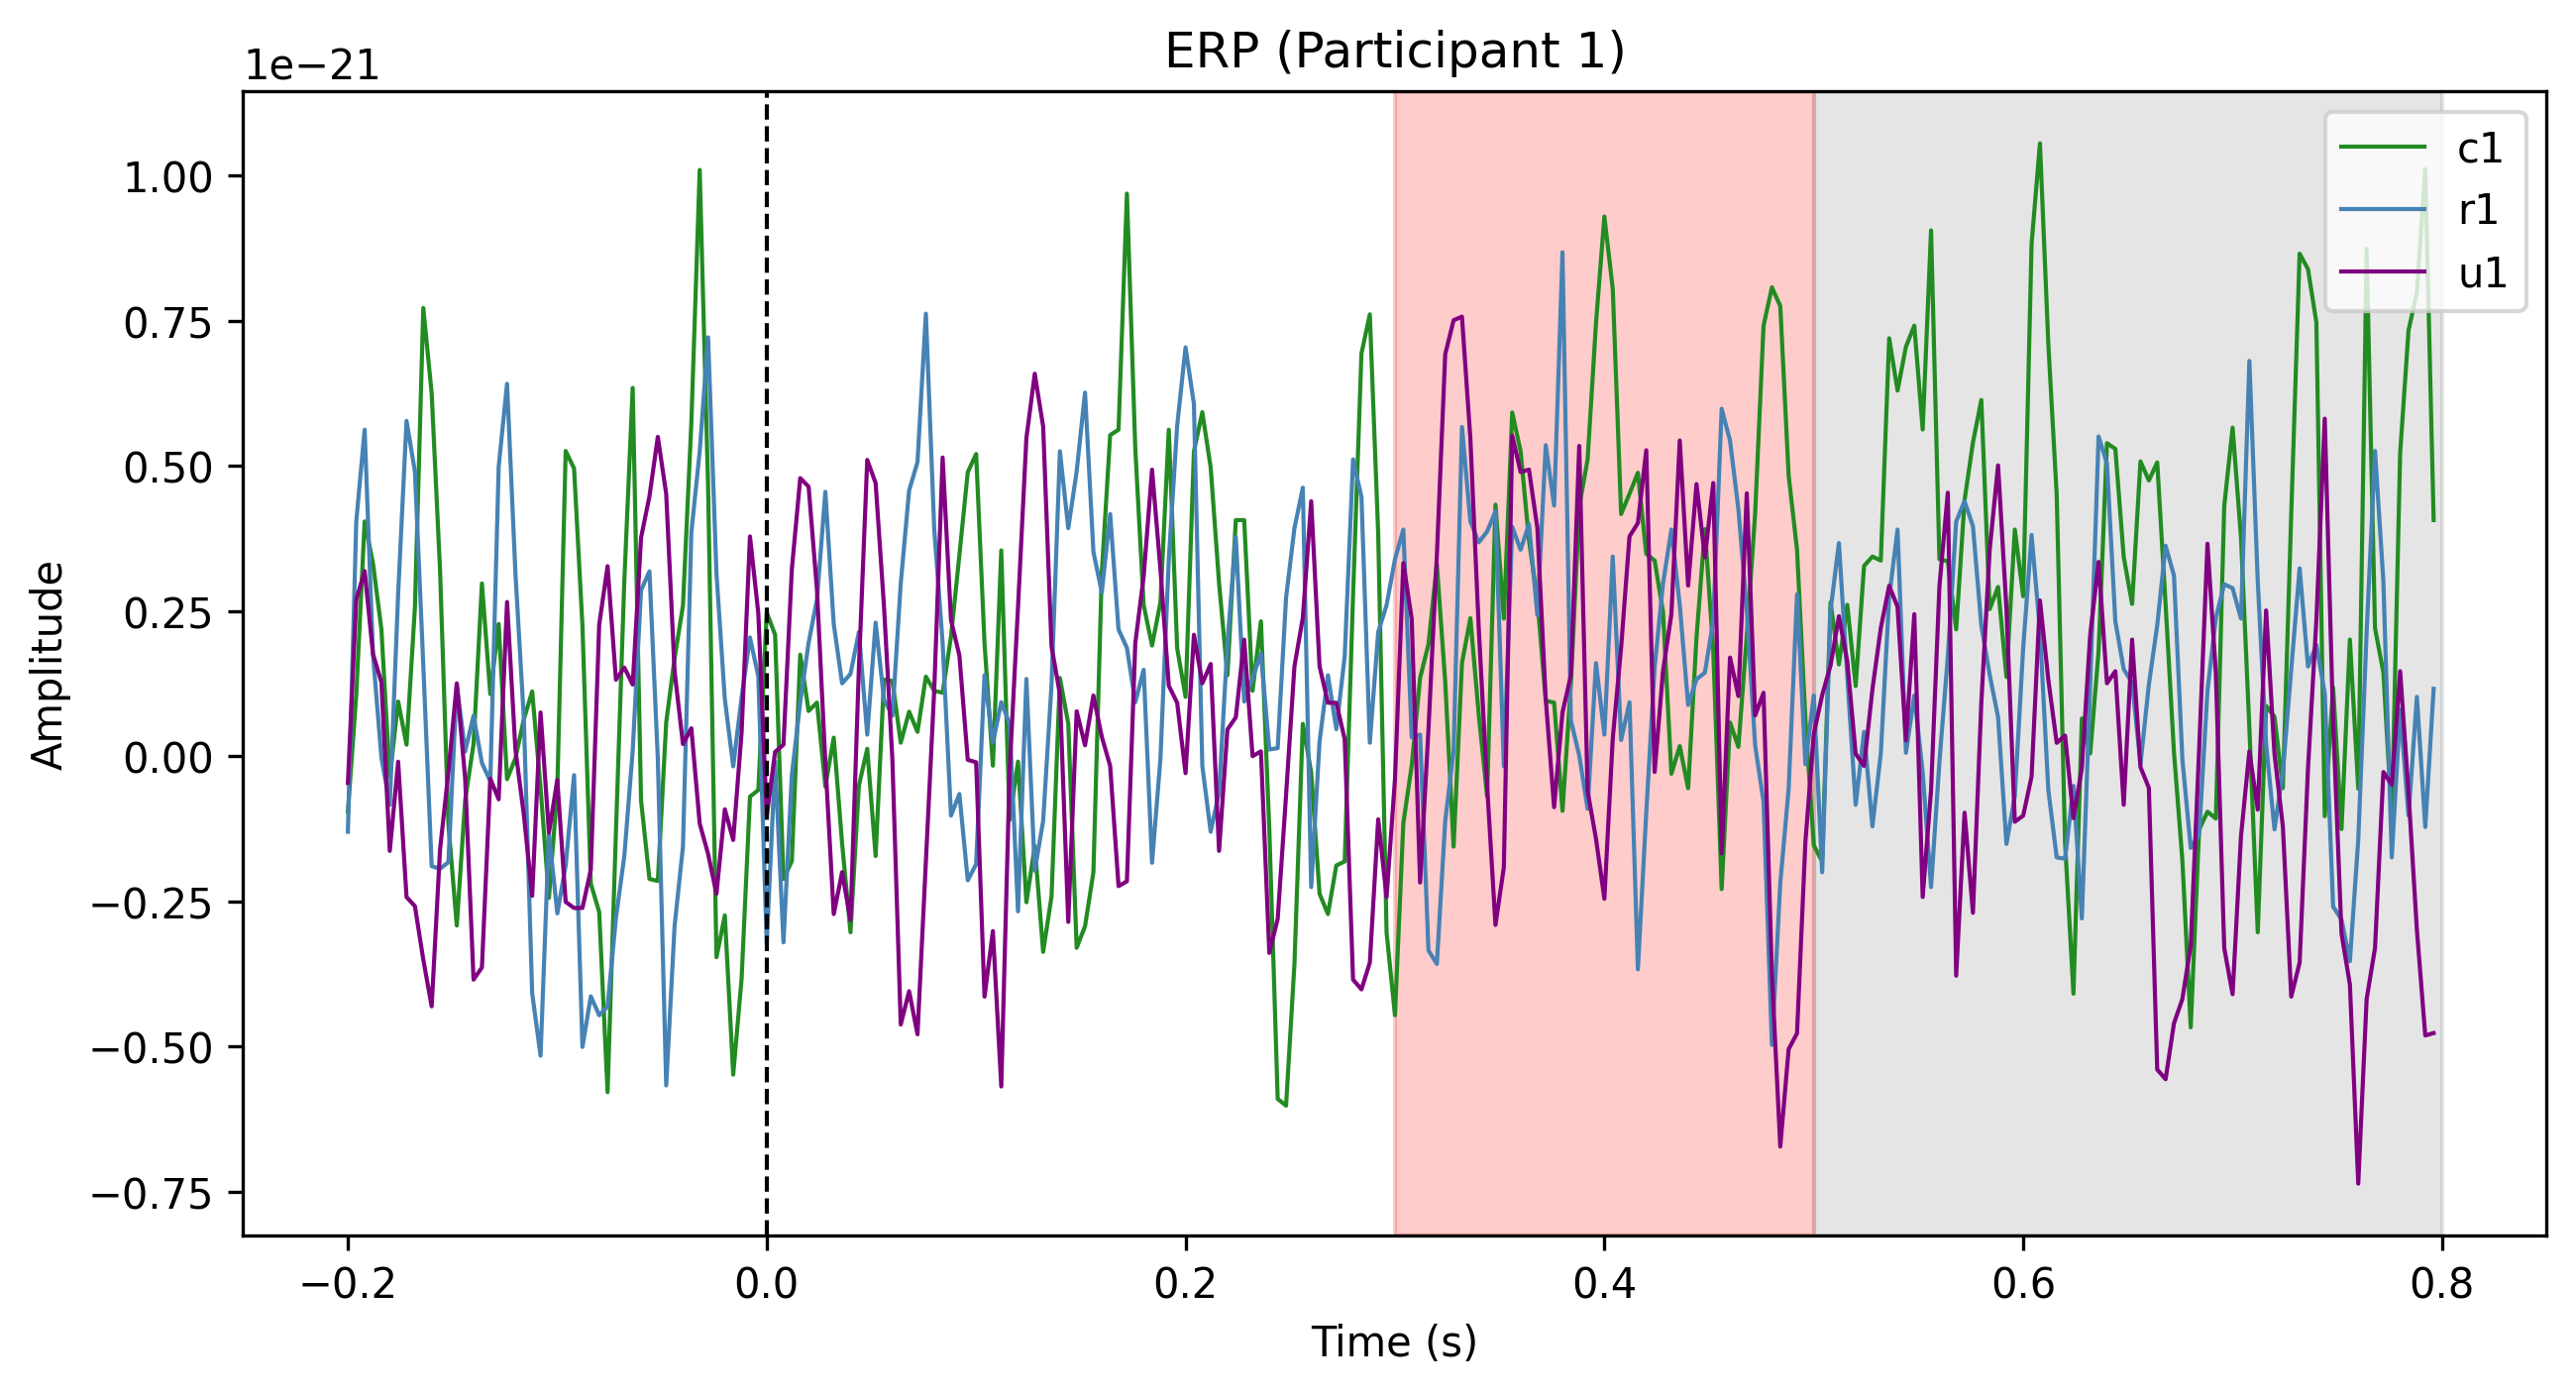

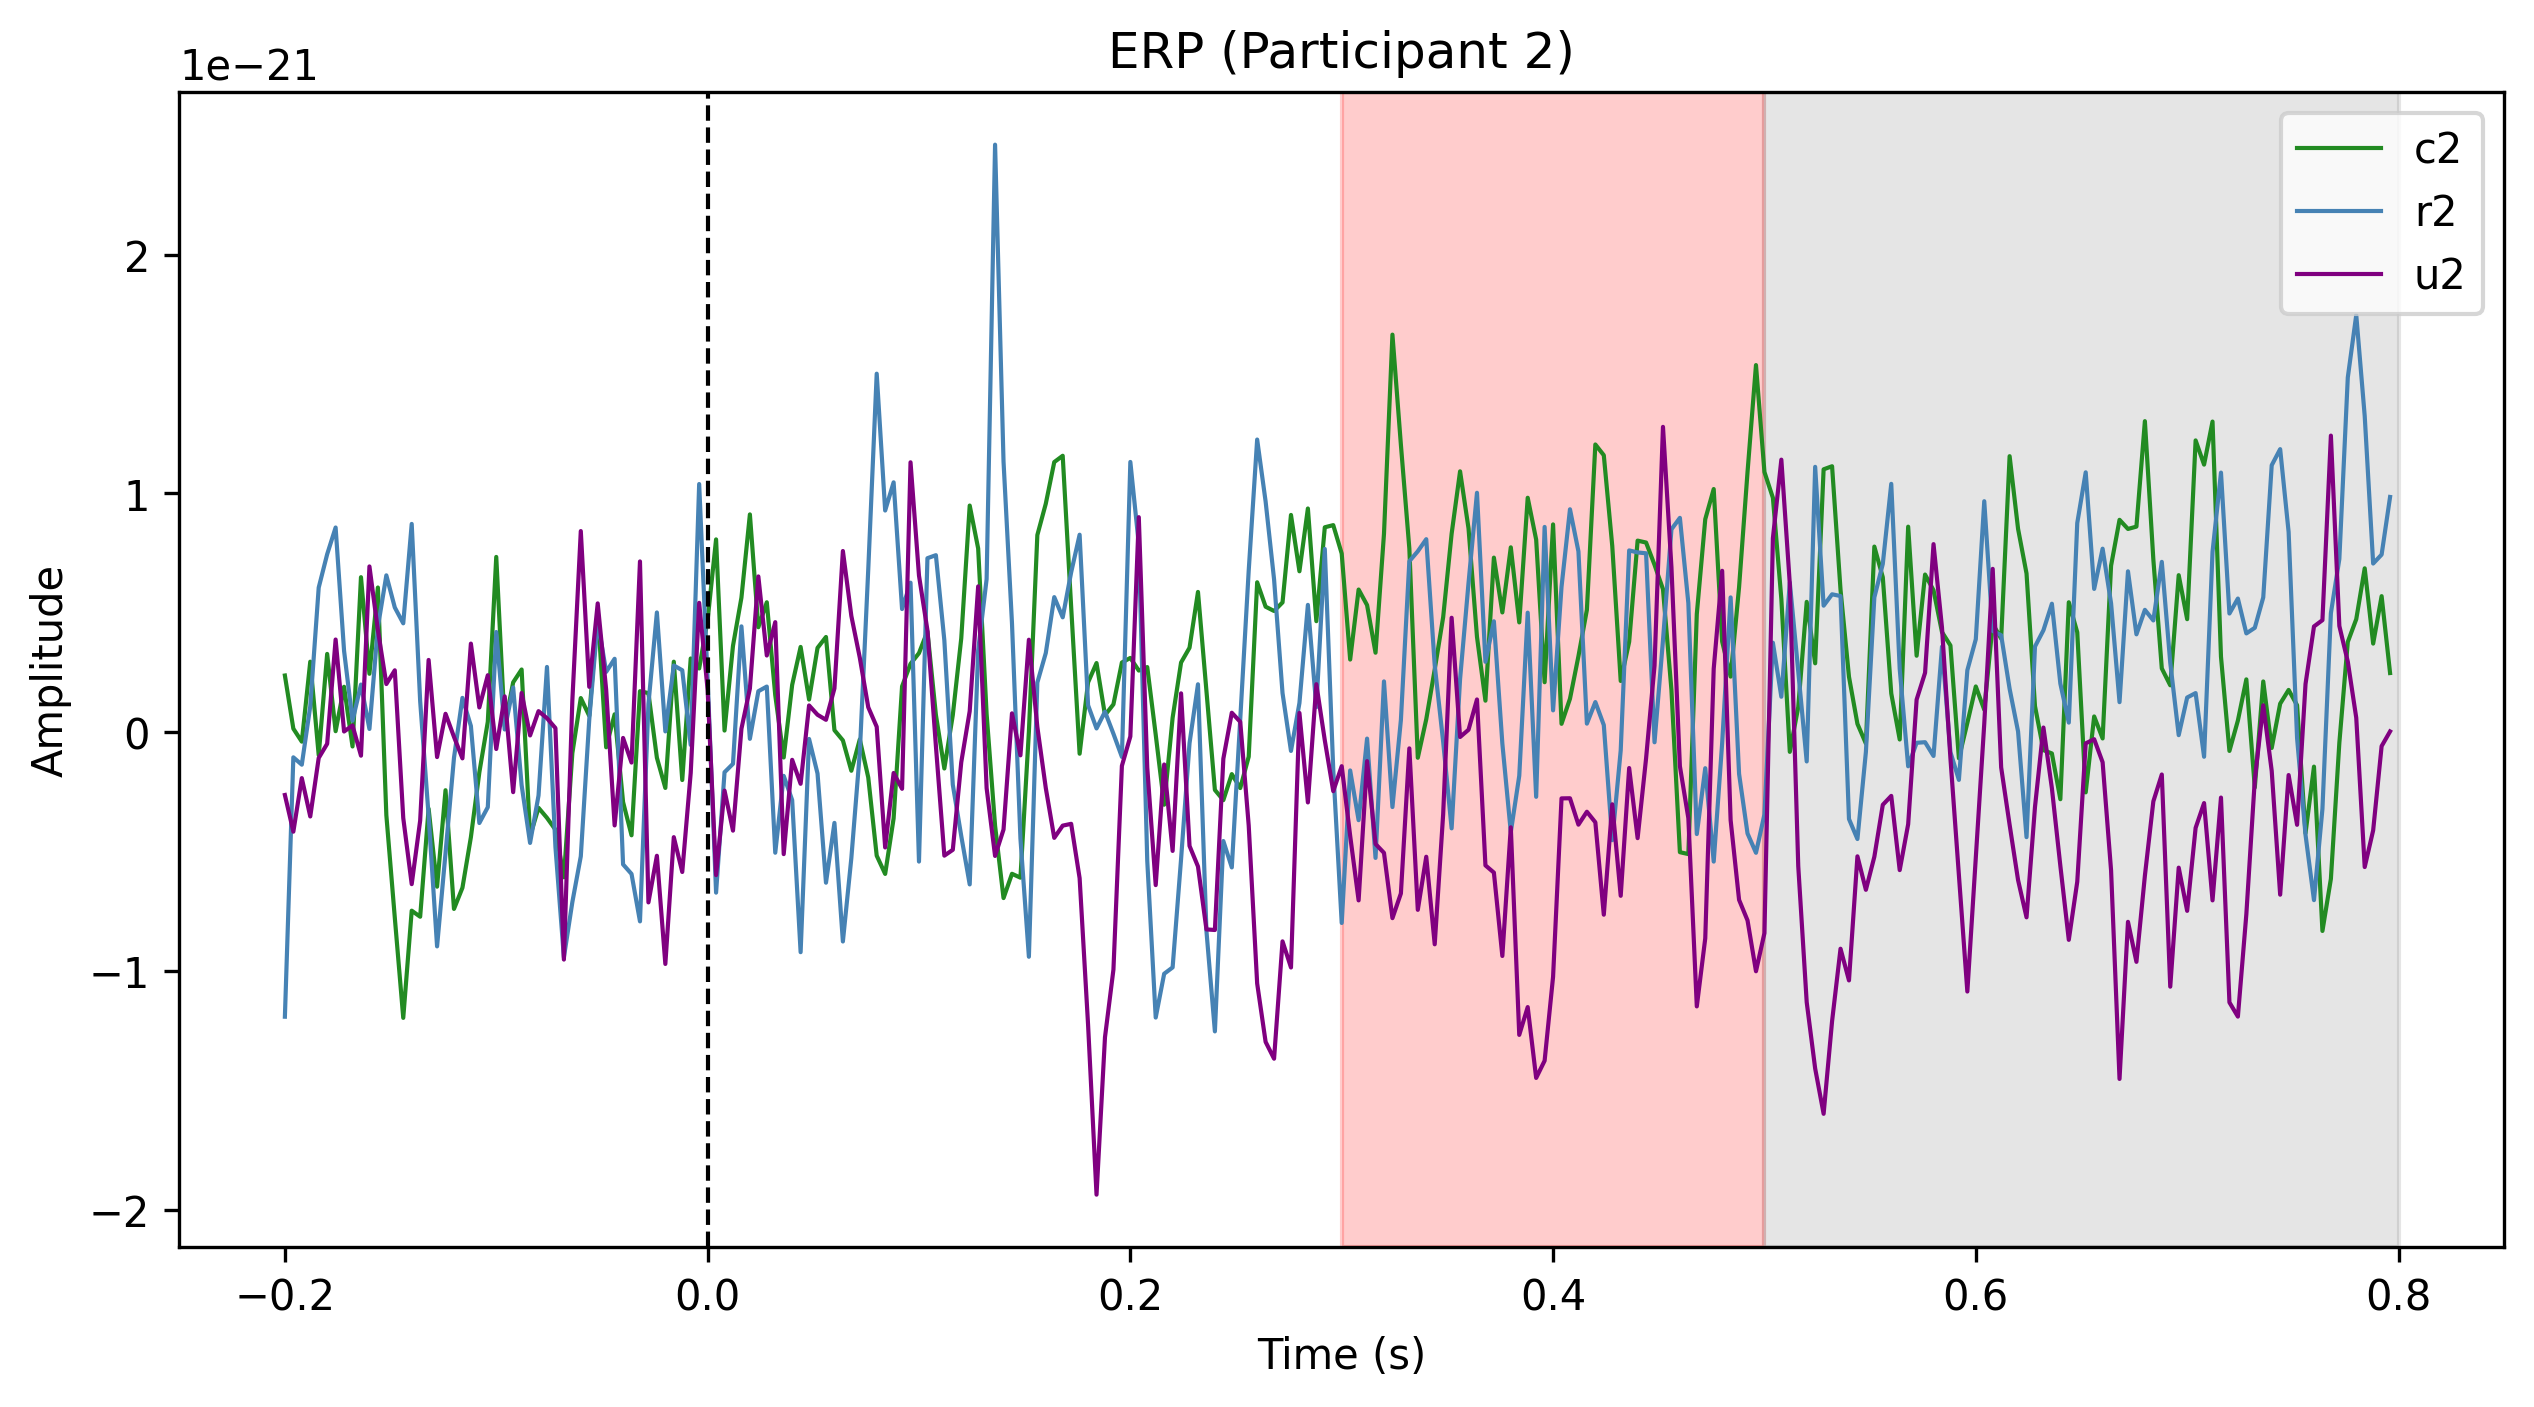

In [25]:
plot_data_c1 = congruent_epochs_1.get_data(copy = True).mean(axis=(0, 1))
plot_data_r1= related_epochs_1.get_data(copy = True).mean(axis=(0, 1))
plot_data_u1 = unrelated_epochs_1.get_data(copy = True).mean(axis=(0, 1))

plot_data_c2 = congruent_epochs_2.get_data(copy = True).mean(axis=(0, 1))
plot_data_r2= related_epochs_2.get_data(copy = True).mean(axis=(0, 1))
plot_data_u2 = unrelated_epochs_2.get_data(copy = True).mean(axis=(0, 1))

times = congruent_epochs_1.times

fig, ax = plt.subplots(1, figsize=(10, 5), dpi=300)

# plot the time window
ax.axvspan(0.3, 0.5, color="red", alpha=0.2)
ax.axvspan(tmin, tmax, color="grey", alpha=0.2)

# plot the time course
ax.plot(times, plot_data_c1.T, label="c1", linewidth=1, color="forestgreen")
ax.plot(times, plot_data_r1.T, label="r1", linewidth=1, color="steelblue")
ax.plot(times, plot_data_u1.T, label="u1", linewidth=1, color="purple")

# vertical line at 0
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)

ax.set(xlabel="Time (s)", ylabel="Amplitude", title="ERP (Participant 1)")
ax.legend(loc = "upper right")

fig, ax = plt.subplots(1, figsize=(10, 5), dpi=300)

# plot the time window
ax.axvspan(0.3, 0.5, color="red", alpha=0.2)
ax.axvspan(tmin, tmax, color="grey", alpha=0.2)


# plot the time course
ax.plot(times, plot_data_c2.T, label="c2", linewidth=1, color="forestgreen")
ax.plot(times, plot_data_r2.T, label="r2", linewidth=1, color="steelblue")
ax.plot(times, plot_data_u2.T, label="u2", linewidth=1, color="purple")

# vertical line at 0
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)

ax.set(xlabel="Time (s)", ylabel="Amplitude", title="ERP (Participant 2)")
ax.legend(loc = "upper right")

## Analysis of the reading times

Extracting the duration of the break in between the sentences

In [26]:
import csv
import pandas as pd

participant_1 = pd.read_csv('/work/Group5/logfile_Melanie_2026-03-24_10h31.04.092.csv')
participant_2 = pd.read_csv('/work/Group5/logfile_Marius_2026-03-24_10h54.05.032.csv')


condition_names = { # changing the condition names to the ones we are using now, since originally we named them a bit differently
    "congruent": "Congruent",
    "logical": "Related",
    "semantic": "Unrelated"
}

participant_1["Condition"] = participant_1["Condition"].replace(condition_names)
participant_2["Condition"] = participant_2["Condition"].replace(condition_names)

print(participant_1.head())
print(participant_2.head())

data_marker_file_own = data_folder / 'group5_own.vmrk'

data_marker_file_other = data_folder / 'group5_other.vmrk'

marker_1 = mne.read_annotations(data_marker_file_other)
marker_2 = mne.read_annotations(data_marker_file_own)

   Unnamed: 0       ID  Age  Gender  Sentence_Number Shown_Word  Reading_time  \
0           0  Melanie   23  Female                1         He      0.837384   
1           1  Melanie   23  Female                1     wanted      0.484605   
2           2  Melanie   23  Female                1         to      0.495372   
3           3  Melanie   23  Female                1       hear      0.493585   
4           4  Melanie   23  Female                1        the      0.407284   

  Condition  Count  Trigger  
0   Related     13      201  
1   Related     14      202  
2   Related     15      203  
3   Related     16      204  
4   Related     17      205  
   Unnamed: 0      ID  Age Gender  Sentence_Number Shown_Word  Reading_time  \
0           0  Marius   22   Male                1         He      0.888715   
1           1  Marius   22   Male                1    carried      0.523180   
2           2  Marius   22   Male                1        his      0.530191   
3           3  Ma

In [27]:

onset_data_1 = pd.DataFrame({
    "onset": marker_1.onset,
    "trigger": marker_1.description
})

onset_data_2 = pd.DataFrame({
    "onset": marker_2.onset,
    "trigger": marker_2.description
})

print(onset_data_1.head())
print(onset_data_2.head())

    onset        trigger
0  71.088  Stimulus/S201
1  71.937  Stimulus/S202
2  72.430  Stimulus/S203
3  72.936  Stimulus/S204
4  73.438  Stimulus/S205
    onset        trigger
0  95.168  Stimulus/S 45
1  96.075  Stimulus/S 46
2  96.609  Stimulus/S 47
3  97.154  Stimulus/S 48
4  97.739  Stimulus/S 49


Combining the behavioral data with the onsets of the stimulus

In [28]:
# checking whether the length of the data frames is the same to ensure that they can be combined and no values are missing
print(len(participant_1))
print(len(onset_data_1))

print(len(participant_2))
print(len(onset_data_2))


1038
1038
1038
1038


In [29]:
participant_1["onset"] = onset_data_1["onset"].values
print(participant_1.head())

participant_2["onset"] = onset_data_2["onset"].values
print(participant_2.head())

   Unnamed: 0       ID  Age  Gender  Sentence_Number Shown_Word  Reading_time  \
0           0  Melanie   23  Female                1         He      0.837384   
1           1  Melanie   23  Female                1     wanted      0.484605   
2           2  Melanie   23  Female                1         to      0.495372   
3           3  Melanie   23  Female                1       hear      0.493585   
4           4  Melanie   23  Female                1        the      0.407284   

  Condition  Count  Trigger   onset  
0   Related     13      201  71.088  
1   Related     14      202  71.937  
2   Related     15      203  72.430  
3   Related     16      204  72.936  
4   Related     17      205  73.438  
   Unnamed: 0      ID  Age Gender  Sentence_Number Shown_Word  Reading_time  \
0           0  Marius   22   Male                1         He      0.888715   
1           1  Marius   22   Male                1    carried      0.523180   
2           2  Marius   22   Male               

In [30]:
# Making a loop that calculates the break duration in seconds 
# after every sentence except the last one, since it doesn't have a sentece after it

breaks_1 = []

breaks_1_dictionary = {
    "Congruent": [],
    "Related": [],
    "Unrelated": []
}

for sentence in range(1, 90):

    last_word_row = participant_1[participant_1["Sentence_Number"] == sentence].iloc[-1]
    next_first_row = participant_1[participant_1["Sentence_Number"] == sentence + 1].iloc[0]

    last_onset = last_word_row["onset"]
    next_onset = next_first_row["onset"]

    last_word = last_word_row["Shown_Word"]
    break_duration = next_onset - last_onset - last_word_row["Reading_time"]
    condition = last_word_row["Condition"]
    

    breaks_1.append([last_word, break_duration, condition])
    breaks_1_dictionary[condition].append(break_duration)


breaks_2 = []

breaks_2_dictionary = {
    "Congruent": [],
    "Related": [],
    "Unrelated": []
}


for sentence in range(1, 90):

    last_word_row = participant_2[participant_2["Sentence_Number"] == sentence].iloc[-1]
    next_first_row = participant_2[participant_2["Sentence_Number"] == sentence + 1].iloc[0]

    last_onset = last_word_row["onset"]
    next_onset = next_first_row["onset"]

    last_word = last_word_row["Shown_Word"]
    break_duration = next_onset - last_onset - last_word_row["Reading_time"]
    condition = last_word_row["Condition"]

    breaks_2.append([last_word, break_duration, condition])
    breaks_2_dictionary[condition].append(break_duration)

# Changing break_1 and break_2 to data frames

breaks_1 = pd.DataFrame(breaks_1, columns=["Shown_Word", "Break_Duration", "Condition"])
breaks_2 = pd.DataFrame(breaks_2, columns=["Shown_Word", "Break_Duration", "Condition"])

print(breaks_1.head())
print(breaks_2.head())

print(breaks_1_dictionary)
print(breaks_2_dictionary)

  Shown_Word  Break_Duration  Condition
0        off        1.481425    Related
1     income        0.844117  Unrelated
2       weak        0.560298    Related
3       read        0.634542    Related
4     school        0.535884    Related
  Shown_Word  Break_Duration  Condition
0       sing        2.617378  Unrelated
1  interview        2.696420  Unrelated
2       disc        3.859896  Unrelated
3      salad        2.743344  Unrelated
4       safe        2.922675  Congruent
{'Congruent': [np.float64(0.5293307999074415), np.float64(0.5700692999810002), np.float64(0.48635270088911403), np.float64(0.4593884986340982), np.float64(0.5763784998357266), np.float64(0.5357964003235054), np.float64(0.597520300164831), np.float64(0.6721249995827634), np.float64(0.4686814985722095), np.float64(0.43265530046821254), np.float64(0.27933640050886765), np.float64(0.47951879893244614), np.float64(0.479908299282215), np.float64(0.5077185998708273), np.float64(0.43961470004916237), np.float64(0.621110400

Boxplots

Text(0.5, 1.0, 'Break Durations by Condition (Participant 1)')

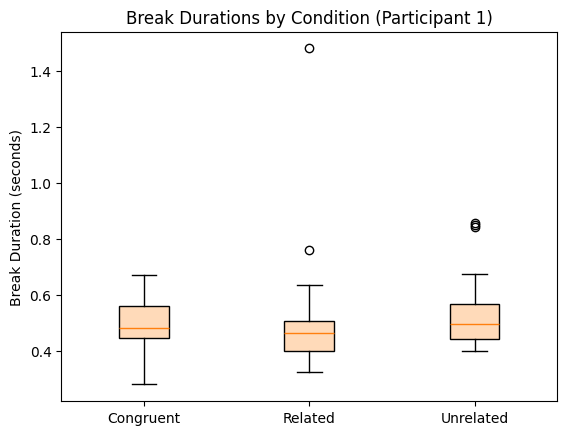

In [31]:
# boxplots

boxplot_1 = plt.boxplot([breaks_1_dictionary["Congruent"],breaks_1_dictionary["Related"], breaks_1_dictionary["Unrelated"]],
    tick_labels = breaks_1_dictionary.keys(), patch_artist=True)

for patch in boxplot_1['boxes']:
    patch.set_facecolor("peachpuff")

plt.ylabel("Break Duration (seconds)")
plt.title("Break Durations by Condition (Participant 1)")


Text(0.5, 1.0, 'Break Durations by Condition (Participant 2)')

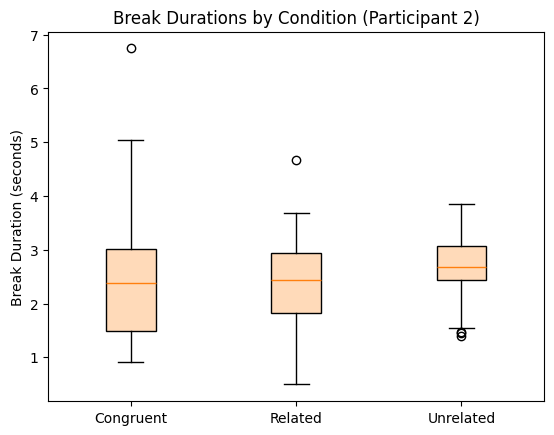

In [32]:
boxplot_2 = plt.boxplot([breaks_2_dictionary["Congruent"],breaks_2_dictionary["Related"], breaks_2_dictionary["Unrelated"]],
    tick_labels = breaks_2_dictionary.keys(), patch_artist=True)


for patch in boxplot_2['boxes']:
    patch.set_facecolor("peachpuff")

plt.ylabel("Break Duration (seconds)")
plt.title("Break Durations by Condition (Participant 2)")

Analysis

In [33]:
# Summaries

summary_list_1 = []

for condition in breaks_1_dictionary.keys():
    values = breaks_1_dictionary[condition]
    stats = {
        'Condition': condition,
        'Mean (s)': np.mean(values),
        'Median (s)': np.median(values),
        'SD (s)': np.std(values),
        'N_trials': len(values)
    }
    summary_list_1.append(stats)

summary_1 = pd.DataFrame(summary_list_1, columns=["Condition", "Mean (s)", "Median (s)", "SD (s)", "N_trials"])
print("Summary for Participant 1")
print(summary_1)

summary_list_2 = []

for condition in breaks_2_dictionary.keys():
    values = breaks_2_dictionary[condition]
    stats = {
        'Condition': condition,
        'Mean (s)': np.mean(values),
        'Median (s)': np.median(values),
        'SD (s)': np.std(values),
        'N_trials': len(values)
    }
    summary_list_2.append(stats)

summary_2 = pd.DataFrame(summary_list_2, columns=["Condition", "Mean (s)", "Median (s)", "SD (s)", "N_trials"])
print("Summary for Participant 2")
print(summary_2)

Summary for Participant 1
   Condition  Mean (s)  Median (s)    SD (s)  N_trials
0  Congruent  0.498053    0.482208  0.092454        30
1    Related  0.496826    0.464328  0.205537        29
2  Unrelated  0.533857    0.494988  0.124932        30
Summary for Participant 2
   Condition  Mean (s)  Median (s)    SD (s)  N_trials
0  Congruent  2.481098    2.388052  1.286295        30
1    Related  2.420959    2.428064  0.960628        30
2  Unrelated  2.621086    2.677115  0.630701        29


## Description of the stimuli

In [34]:
# calculating sentence and critical word lengths

sentences_length = []

sent_len_by_condition = {
    "Congruent": [],
    "Related": [],
    "Unrelated": []
}

critical_words_lengths = []

crit_words_by_condition  = {
    "Congruent": [],
    "Related": [],
    "Unrelated": []
}

for sentence in range(1, 91):

    first_word_row = participant_1[participant_1["Sentence_Number"] == sentence].iloc[0]
    last_word_row = participant_1[participant_1["Sentence_Number"] == sentence].iloc[-1]

    first_count = first_word_row["Count"]
    last_count = last_word_row["Count"]
    critical_word = str(last_word_row["Shown_Word"])
    critical_word_length = len(critical_word)

    sentence_length = last_count - first_count + 1
    condition = last_word_row["Condition"]

    sentences_length.append(sentence_length)
    sent_len_by_condition[condition].append(sentence_length)
    critical_words_lengths.append(critical_word_length)
    crit_words_by_condition[condition].append(critical_word_length)


## sentences

print(f"Mean Sentence Length: {np.mean(sentences_length):.2f} words")
print(f"Standard Deviation: {np.std(sentences_length):.2f} words")
print(f"Range: {np.min(sentences_length)} - {np.max(sentences_length)} words")

summary_list_sentences = []

for condition in sent_len_by_condition.keys():
    values = sent_len_by_condition[condition]
    stats = {
        'Condition': condition,
        'Mean length (words)': round(np.mean(values), 2),
        'SD (words)': round(np.std(values), 2),
        'Range (words)': f"{np.min(values)} - {np.max(values)}"
    }
    summary_list_sentences.append(stats)

summary_sentences = pd.DataFrame(summary_list_sentences, columns=["Condition", "Mean length (words)", "SD (words)", "Range (words)"])
print("Summary of the sentences by condition")
print(summary_sentences)



## critical words

print(f"Mean Critical Word Length: {np.mean(critical_words_lengths):.2f} characters")
print(f"Standard Deviation: {np.std(critical_words_lengths):.2f} characters")
print(f"Range: {np.min(critical_words_lengths)} - {np.max(critical_words_lengths)} characters")

summary_list_critical_words = []

for condition in crit_words_by_condition.keys():
    values = crit_words_by_condition[condition]
    stats = {
        'Condition': condition,
        'Mean length (characters)': round(np.mean(values), 2),
        'SD (characters)': round(np.std(values), 2),
        'Range (characters)': f"{np.min(values)} - {np.max(values)}"
    }
    summary_list_critical_words.append(stats)

summary_critical_words = pd.DataFrame(summary_list_critical_words, columns=["Condition", "Mean length (characters)", "SD (characters)", "Range (characters)"])
print("Summary of the critical words by condition")
print(summary_critical_words)



Mean Sentence Length: 11.53 words
Standard Deviation: 1.94 words
Range: 8 - 17 words
Summary of the sentences by condition
   Condition  Mean length (words)  SD (words) Range (words)
0  Congruent                11.33        1.72        8 - 15
1    Related                11.30        2.07        8 - 16
2  Unrelated                11.97        1.96        9 - 17
Mean Critical Word Length: 5.33 characters
Standard Deviation: 1.84 characters
Range: 2 - 13 characters
Summary of the critical words by condition
   Condition  Mean length (characters)  SD (characters) Range (characters)
0  Congruent                       5.3             1.72              2 - 9
1    Related                       4.8             1.92             3 - 13
2  Unrelated                       5.9             1.72              4 - 9


Citing packages

In [35]:
import matplotlib
import scipy

print(f"MNE: {mne.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Scipy: {scipy.__version__}")
print(f"Csv: {csv.__version__}")
print(f"Pandas: {pd.__version__}")

MNE: 1.11.0
Numpy: 2.4.3
Matplotlib: 3.10.0
Scipy: 1.17.1
Csv: 1.0
Pandas: 3.0.1
